# NOTEBOOK MODEL

## Import libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy.stats import chi2_contingency
from itertools import combinations
from scipy.stats import f_oneway

import os
import re

from IPython.display import display, Markdown

import missingno as msno
import sys

from rapidfuzz import process, fuzz

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

from itertools import product

import warnings
warnings.filterwarnings('ignore')

In [2]:
df_modelo = pd.read_csv(r'..\00_Data\00_Processed\df_modelo.csv')

In [3]:
df_modelo.columns

Index(['person_id', 'decile_score', 'rawscore', 'v_decile_score', 'is_recid',
       'is_violent_recid', 'two_year_recid', 'sex', 'race', 'age', 'age_cat',
       'total_priors_count', 'adult_priors_count', 'juv_priors_count',
       'c_charge_degree', 'maritalstatus', 'juv_fel_count', 'juv_misd_count',
       'juv_other_count', 'is_violent', 'is_drug', 'is_property', 'is_fraud',
       'is_weapon', 'is_traffic', 'is_sexual', 'is_public_disorder',
       'is_justice_related', 'no_charge', 'maritalstatus_other',
       'maritalstatus_separated', 'maritalstatus_significant other',
       'log_juv_priors_count', 'log_adult_priors_count', 'adult_priors_freq',
       'adult_priors_freq_2', 'adult_priors_freq_3'],
      dtype='object')

In [4]:
#eliminate extreme outliers

lista_col_outliers = [
    'age',
    'total_priors_count',
    'juv_priors_count',
]

for col in lista_col_outliers:

    upper = df_modelo[col].quantile(0.99)

    df_sin_outliers = df_modelo[
        df_modelo[col] <= upper
    ]

## Test models

### Logistic regression models and bagging classifiers

#### Test #1

In [5]:
lista_columnas_dropear = ['two_year_recid','person_id', 'decile_score', 'rawscore', 'v_decile_score', 'is_recid', 'is_violent_recid', 'maritalstatus', 'race', 'adult_priors_freq', 'adult_priors_freq_2',
       'adult_priors_freq_3',  'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'sex', "juv_priors_count", "adult_priors_count", "log_juv_priors_count", "log_adult_priors_count", 'maritalstatus_other', 'maritalstatus_separated', 'maritalstatus_significant other', 'age_cat']


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.79      0.65      0.71       779
           1       0.52      0.69      0.60       435

    accuracy                           0.66      1214
   macro avg       0.66      0.67      0.65      1214
weighted avg       0.69      0.66      0.67      1214

ROC AUC: 0.7273855370132648
              Variable  Coeficiente
0                  age    -0.046107
1   total_priors_count     0.158496
2      c_charge_degree    -0.165317
3           is_violent    -0.308781
4              is_drug    -0.078068
5          is_property    -0.165979
6             is_fraud    -0.285637
7            is_weapon    -0.081290
8           is_traffic    -0.331928
9            is_sexual     0.000000
10  is_public_disorder     0.000000
11  is_justice_related     0.000000
12           no_charge    -0.172380
Matriz de confusión:




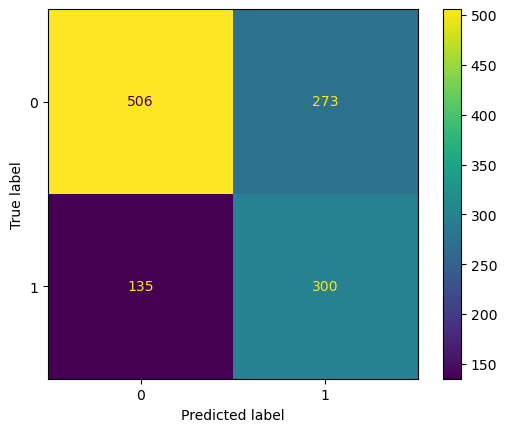

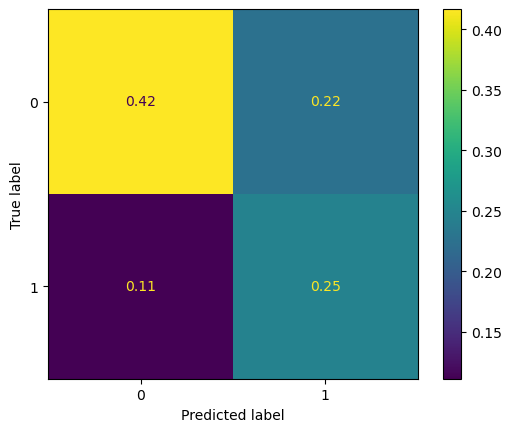

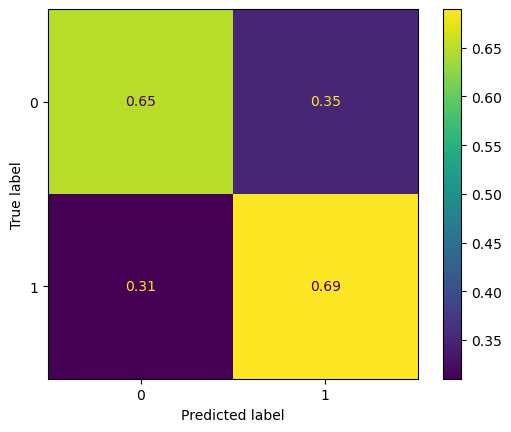



Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.79      0.65      0.71       779
           1       0.52      0.69      0.60       435

    accuracy                           0.66      1214
   macro avg       0.66      0.67      0.65      1214
weighted avg       0.69      0.66      0.67      1214

ROC AUC: 0.7273855370132648

=== Raza: other ===


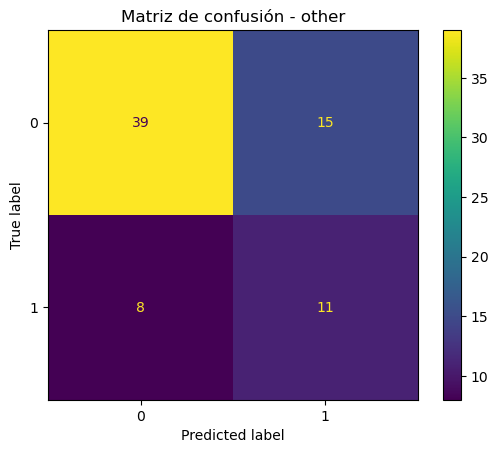

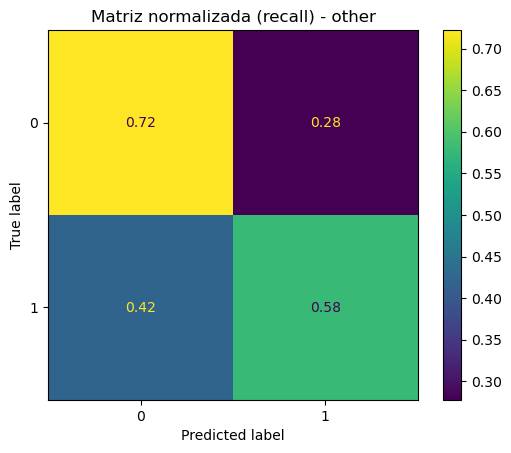


=== Raza: african-american ===


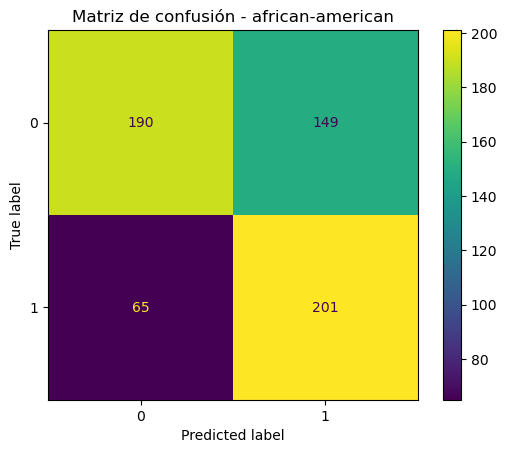

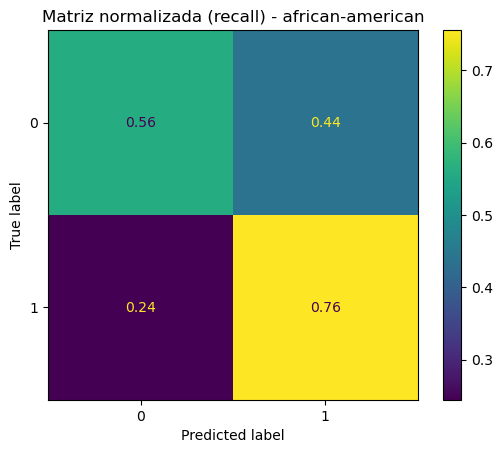


=== Raza: hispanic ===


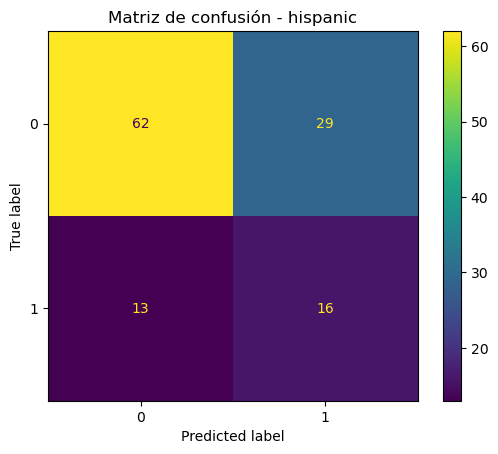

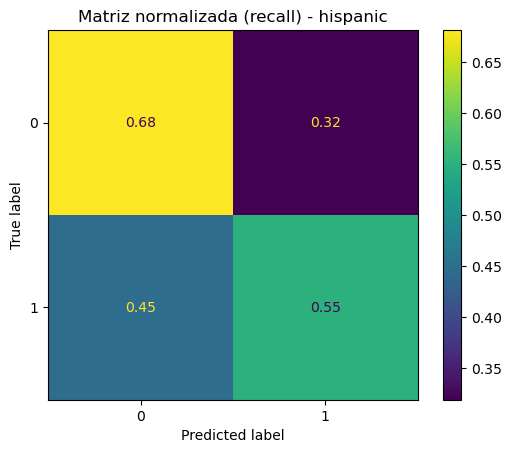


=== Raza: caucasian ===


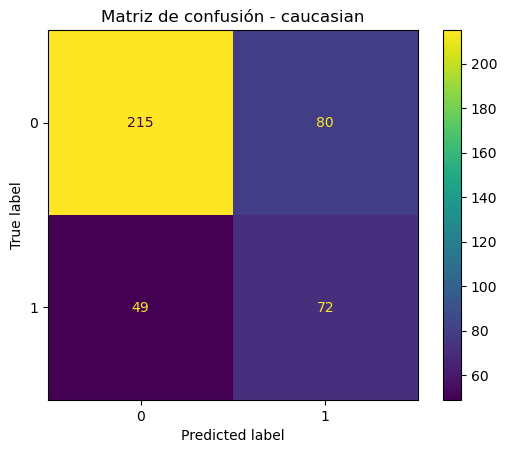

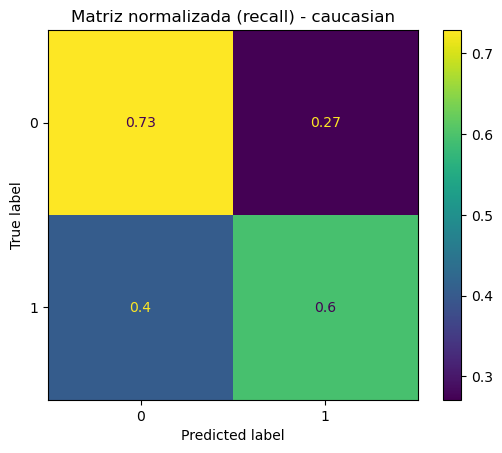

In [6]:
X = df_sin_outliers.drop(columns=lista_columnas_dropear)
y = df_sin_outliers['two_year_recid']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 69, stratify = y)

model = LogisticRegression(max_iter=1000, penalty='l1', solver='liblinear', class_weight='balanced')

model.fit(X_train, y_train)

y_proba = model.predict_proba(X_test)[:,1]
y_pred = (y_proba >= 0.505).astype(int)


print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': model.coef_[0]
})

print(coeficientes)

print("Matriz de confusión:")
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred))
disp.plot()
print("\n")
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize= "all"))
disp.plot()
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize= "true"))
disp.plot()
plt.show()
print("\n")
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

race_test = df_sin_outliers.loc[X_test.index, 'race']

razas = race_test.unique()

#generate confusion matrices by race

for raza in razas:
    idx = race_test == raza
    
    y_true_r = y_test[idx]
    y_pred_r = y_pred[idx]
    
    print(f"\n=== Raza: {raza} ===")
    
    cm = confusion_matrix(y_true_r, y_pred_r)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"Matriz de confusión - {raza}")
    plt.show()
    
    cm_norm = confusion_matrix(y_true_r, y_pred_r, normalize='true')
    disp = ConfusionMatrixDisplay(cm_norm)
    disp.plot()
    plt.title(f"Matriz normalizada (recall) - {raza}")
    plt.show()

Matriz de confusión:




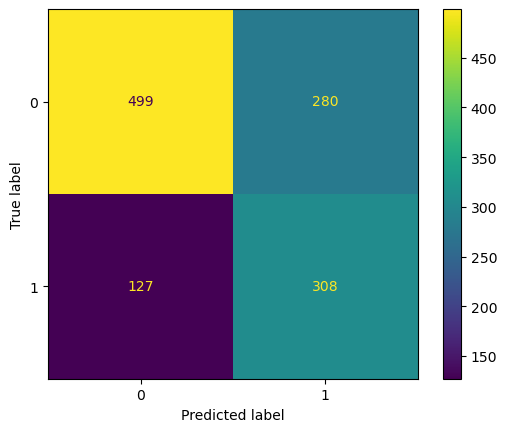

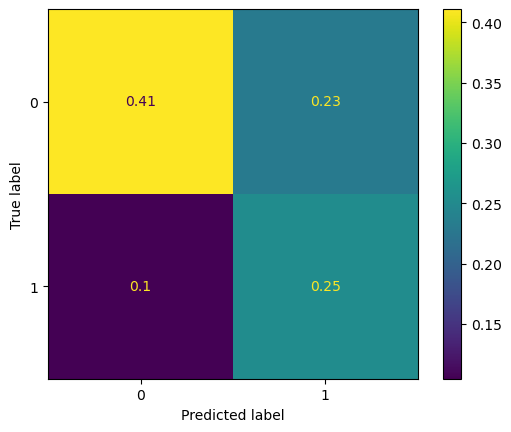

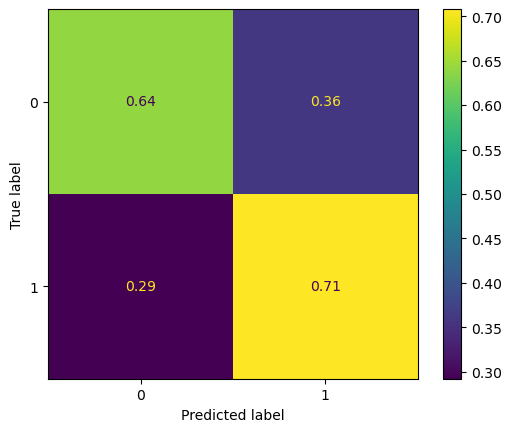



Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.80      0.64      0.71       779
           1       0.52      0.71      0.60       435

    accuracy                           0.66      1214
   macro avg       0.66      0.67      0.66      1214
weighted avg       0.70      0.66      0.67      1214

ROC AUC: 0.7262110279904976

=== Raza: other ===


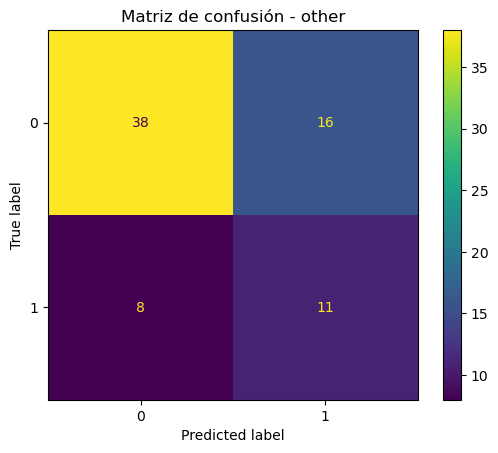

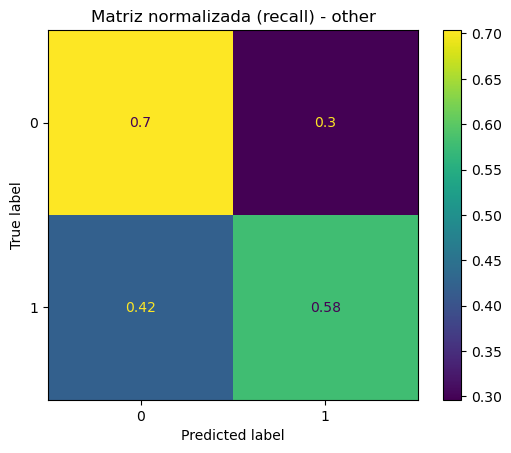


=== Raza: african-american ===


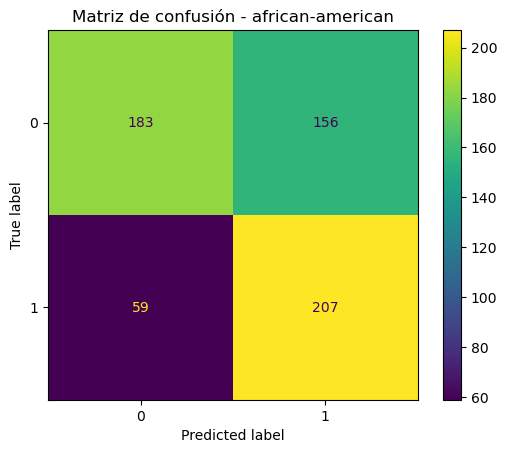

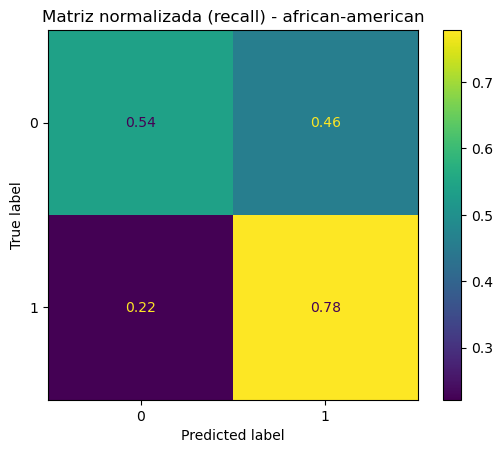


=== Raza: hispanic ===


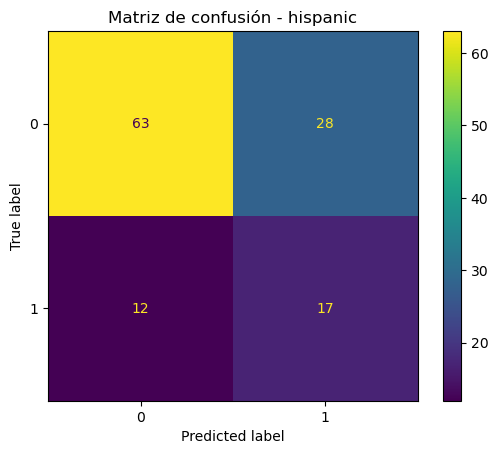

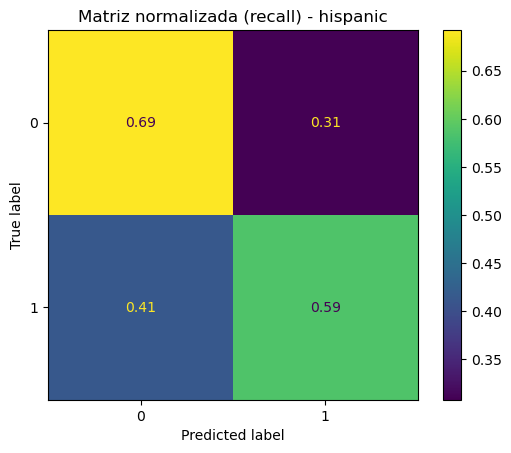


=== Raza: caucasian ===


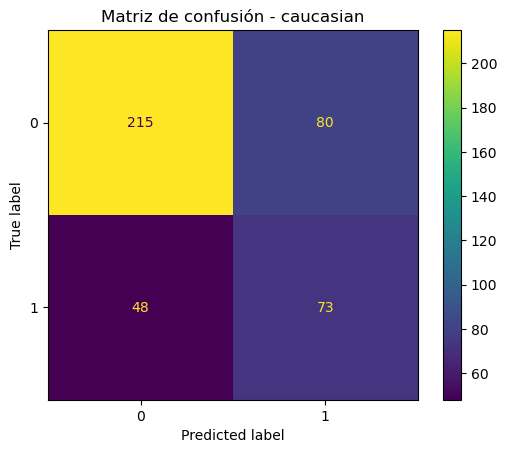

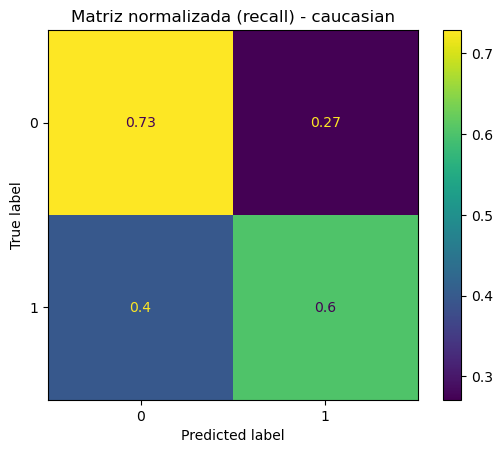

In [7]:
model = BaggingClassifier(
    estimator=LogisticRegression(penalty='l1', solver='liblinear'),
    n_estimators=10
)

model.fit(X_train, y_train)

y_proba = model.predict_proba(X_test)[:,1]
y_pred = (y_proba >= 0.37).astype(int)


print("Matriz de confusión:")
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred))
disp.plot()
print("\n")
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize= "all"))
disp.plot()
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize= "true"))
disp.plot()
plt.show()
print("\n")
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

race_test = df_sin_outliers.loc[X_test.index, 'race']

razas = race_test.unique()

#generate confusion matrices by race

for raza in razas:
    idx = race_test == raza
    
    y_true_r = y_test[idx]
    y_pred_r = y_pred[idx]
    
    print(f"\n=== Raza: {raza} ===")
    
    cm = confusion_matrix(y_true_r, y_pred_r)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"Matriz de confusión - {raza}")
    plt.show()
    
    cm_norm = confusion_matrix(y_true_r, y_pred_r, normalize='true')
    disp = ConfusionMatrixDisplay(cm_norm)
    disp.plot()
    plt.title(f"Matriz normalizada (recall) - {raza}")
    plt.show()

#### Test #2

In [9]:
lista_columnas_dropear = ['two_year_recid','person_id', 'decile_score', 'rawscore', 'v_decile_score', 'is_recid', 'is_violent_recid', 'maritalstatus', 'race', 'adult_priors_freq', 'adult_priors_freq_2',
       'adult_priors_freq_3', 'maritalstatus_other', 'maritalstatus_separated', 'maritalstatus_significant other', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'sex', 'total_priors_count',
       'log_juv_priors_count', 'log_adult_priors_count', 'maritalstatus_other', 'maritalstatus_separated', 'maritalstatus_significant other', 'age_cat']


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.79      0.69      0.73       779
           1       0.54      0.67      0.60       435

    accuracy                           0.68      1214
   macro avg       0.67      0.68      0.67      1214
weighted avg       0.70      0.68      0.69      1214

ROC AUC: 0.7308662741799832
              Variable  Coeficiente
0                  age    -0.042732
1   adult_priors_count     0.151975
2     juv_priors_count     0.371110
3      c_charge_degree    -0.187195
4           is_violent    -0.370191
5              is_drug    -0.166913
6          is_property    -0.241651
7             is_fraud    -0.354841
8            is_weapon    -0.124187
9           is_traffic    -0.380794
10           is_sexual    -0.144833
11  is_public_disorder    -0.039677
12  is_justice_related    -0.052241
13           no_charge    -0.227252
Matriz de confusión:




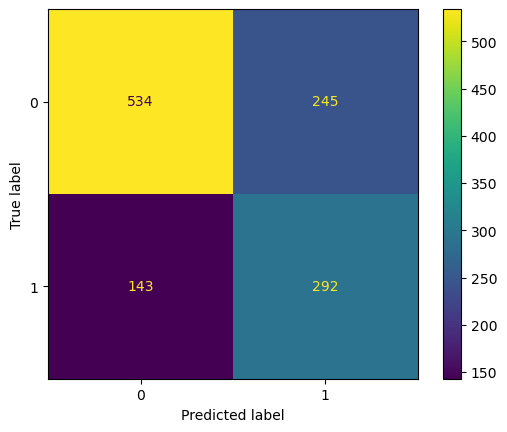

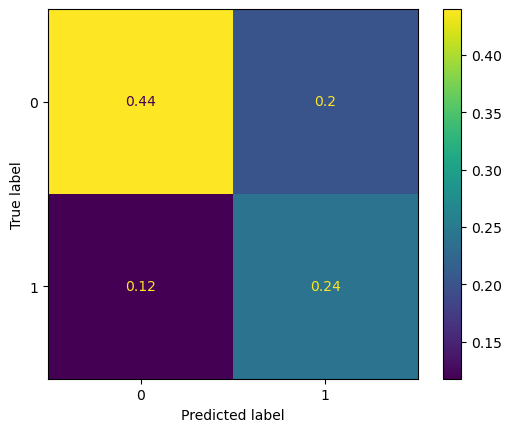

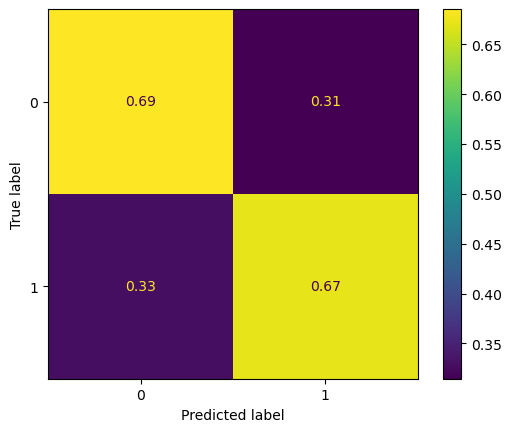



Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.79      0.69      0.73       779
           1       0.54      0.67      0.60       435

    accuracy                           0.68      1214
   macro avg       0.67      0.68      0.67      1214
weighted avg       0.70      0.68      0.69      1214

ROC AUC: 0.7308662741799832

=== Raza: other ===


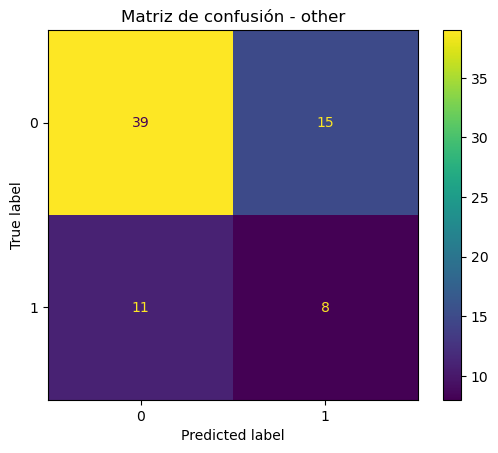

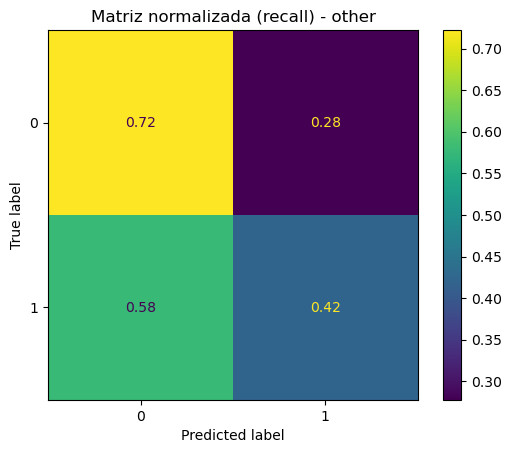


=== Raza: african-american ===


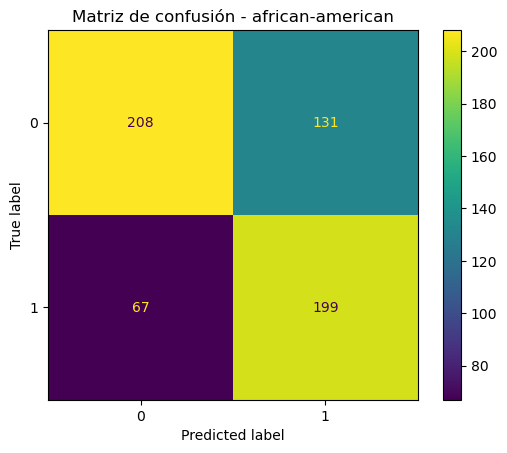

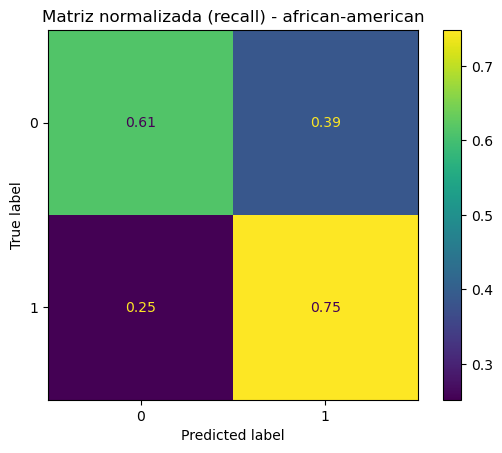


=== Raza: hispanic ===


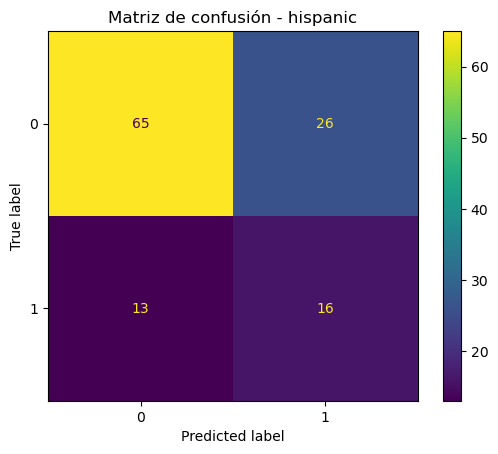

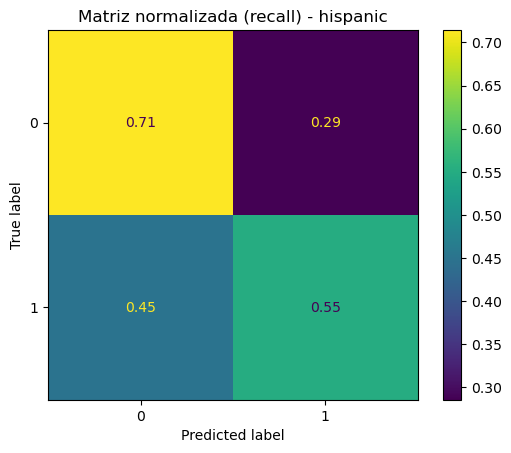


=== Raza: caucasian ===


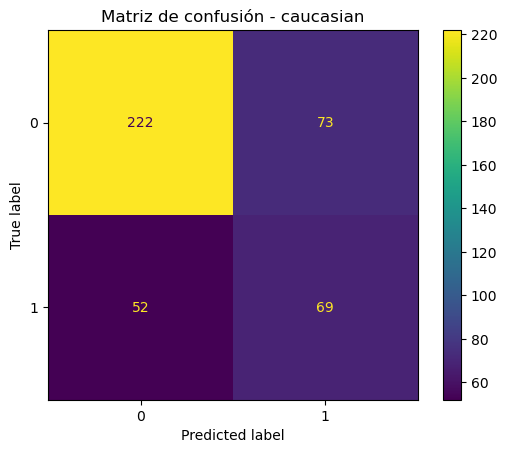

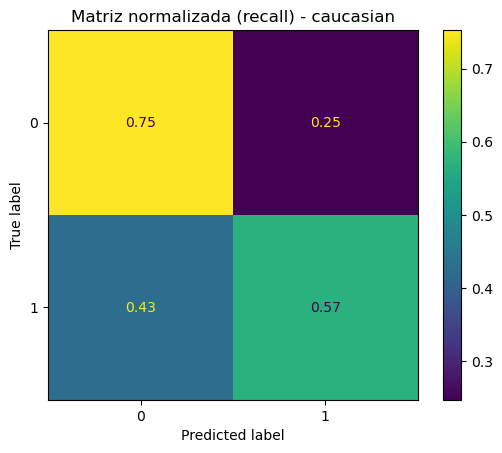

In [ ]:
X1 = df_sin_outliers.drop(columns=lista_columnas_dropear)
y1 = df_sin_outliers['two_year_recid']

X1_train, X1_test, y1_train, y1_test, = train_test_split(X1, y1, test_size = 0.2, random_state = 69, stratify = y1)

model1 = LogisticRegression(max_iter=1000, penalty='l2', solver='liblinear', class_weight='balanced')

model1.fit(X1_train, y1_train)

y1_proba = model1.predict_proba(X1_test)[:,1]
y1_pred = (y1_proba >= 0.515).astype(int)

print("\nReporte de clasificación:")
print(classification_report(y1_test, y1_pred))
print("ROC AUC:", roc_auc_score(y1_test, y1_proba))

coeficientes = pd.DataFrame({
    'Variable': X1.columns,
    'Coeficiente': model1.coef_[0]
})

print(coeficientes)

print("Matriz de confusión:")
disp = ConfusionMatrixDisplay(confusion_matrix(y1_test, y1_pred))
disp.plot()
print("\n")
disp = ConfusionMatrixDisplay(confusion_matrix(y1_test, y1_pred, normalize= "all"))
disp.plot()
disp = ConfusionMatrixDisplay(confusion_matrix(y1_test, y1_pred, normalize= "true"))
disp.plot()
plt.show()
print("\n")
print("Reporte de clasificación:")
print(classification_report(y1_test, y1_pred))
print("ROC AUC:", roc_auc_score(y1_test, y1_proba))

race_test = df_sin_outliers.loc[X1_test.index, 'race']

razas = race_test.unique()

#generate confusion matrices by race

for raza in razas:
    idx = race_test == raza
    
    y_true_r = y1_test[idx]
    y_pred_r = y1_pred[idx]
    
    print(f"\n=== Raza: {raza} ===")
    
    cm = confusion_matrix(y_true_r, y_pred_r)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"Matriz de confusión - {raza}")
    plt.show()

    cm_norm = confusion_matrix(y_true_r, y_pred_r, normalize='true')
    disp = ConfusionMatrixDisplay(cm_norm)
    disp.plot()
    plt.title(f"Matriz normalizada (recall) - {raza}")
    plt.show()

In [ ]:
model1 = BaggingClassifier(
    estimator=LogisticRegression(penalty='l1', solver='liblinear'),
    n_estimators=10
)

model1.fit(X1_train, y1_train, sample_weight = w1_train)

y1_proba = model1.predict_proba(X1_test)[:,1]
y1_pred = (y1_proba >= 0.37).astype(int)


print("Matriz de confusión:")
disp = ConfusionMatrixDisplay(confusion_matrix(y1_test, y1_pred))
disp.plot()
print("\n")
disp = ConfusionMatrixDisplay(confusion_matrix(y1_test, y1_pred, normalize= "all"))
disp.plot()
disp = ConfusionMatrixDisplay(confusion_matrix(y1_test, y1_pred, normalize= "true"))
disp.plot()
plt.show()
print("\n")
print("Reporte de clasificación:")
print(classification_report(y1_test, y1_pred))
print("ROC AUC:", roc_auc_score(y1_test, y1_proba))

race_test = df_sin_outliers.loc[X1_test.index, 'race']

razas = race_test.unique()

#generate confusion matrices by race

for raza in razas:
    idx = race_test == raza
    
    y_true_r = y1_test[idx]
    y_pred_r = y1_pred[idx]
    
    print(f"\n=== Raza: {raza} ===")
    
    cm = confusion_matrix(y_true_r, y_pred_r)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"Matriz de confusión - {raza}")
    plt.show()
    
    cm_norm = confusion_matrix(y_true_r, y_pred_r, normalize='true')
    disp = ConfusionMatrixDisplay(cm_norm)
    disp.plot()
    plt.title(f"Matriz normalizada (recall) - {raza}")
    plt.show()

#### Test #3

In [8]:
lista_columnas_dropear = ['two_year_recid','person_id', 'decile_score', 'rawscore', 'v_decile_score', 'is_recid', 'is_violent_recid', 'maritalstatus', 'race', 'adult_priors_freq',
       'adult_priors_freq_2', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'total_priors_count', 'maritalstatus_other', 'maritalstatus_separated', 'maritalstatus_significant other',
       'adult_priors_count', 'juv_priors_count', 'age_cat']


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.80      0.64      0.71       779
           1       0.52      0.71      0.60       435

    accuracy                           0.66      1214
   macro avg       0.66      0.67      0.66      1214
weighted avg       0.70      0.66      0.67      1214

ROC AUC: 0.7402357871128621
                  Variable  Coeficiente
0                      sex    -0.359875
1                      age    -0.041586
2          c_charge_degree    -0.152418
3               is_violent    -0.251823
4                  is_drug    -0.087988
5              is_property    -0.101525
6                 is_fraud    -0.252497
7                is_weapon    -0.092605
8               is_traffic    -0.348709
9                is_sexual     0.000000
10      is_public_disorder     0.000000
11      is_justice_related    -0.021362
12               no_charge    -0.250759
13    log_juv_priors_count     0.727216
14  log_adult_prio

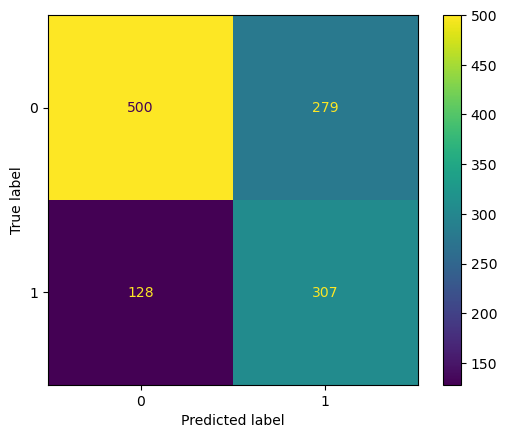

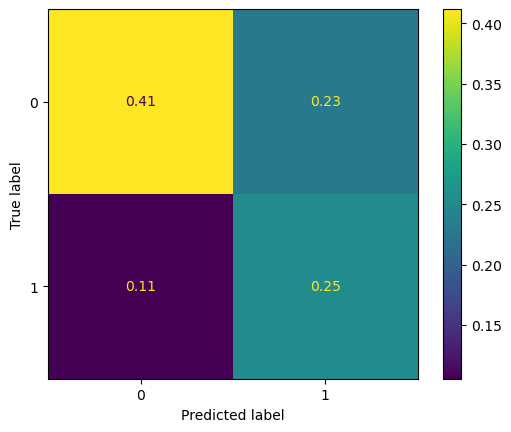

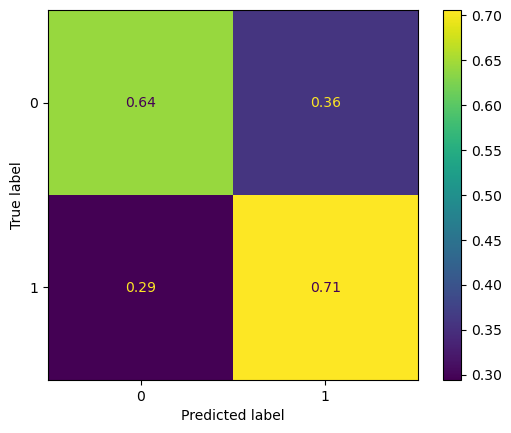



Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.80      0.64      0.71       779
           1       0.52      0.71      0.60       435

    accuracy                           0.66      1214
   macro avg       0.66      0.67      0.66      1214
weighted avg       0.70      0.66      0.67      1214

ROC AUC: 0.7402357871128621

=== Raza: other ===


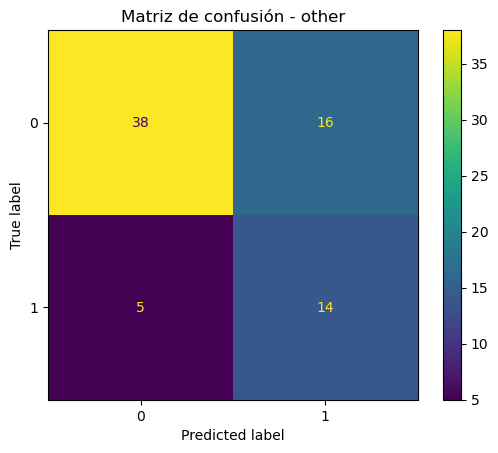

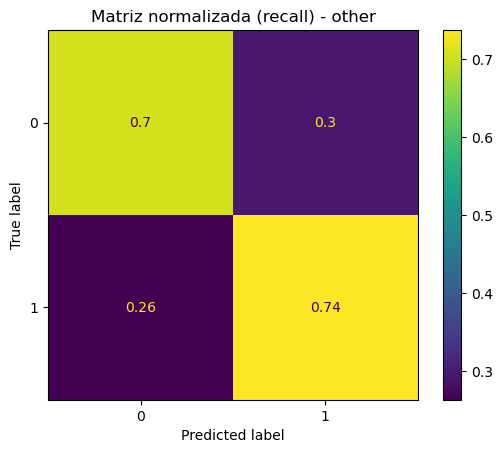


=== Raza: african-american ===


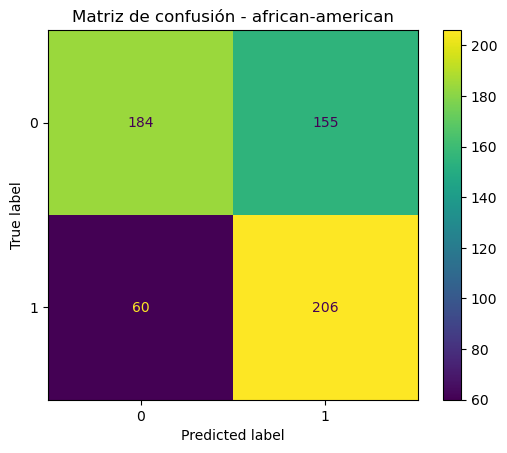

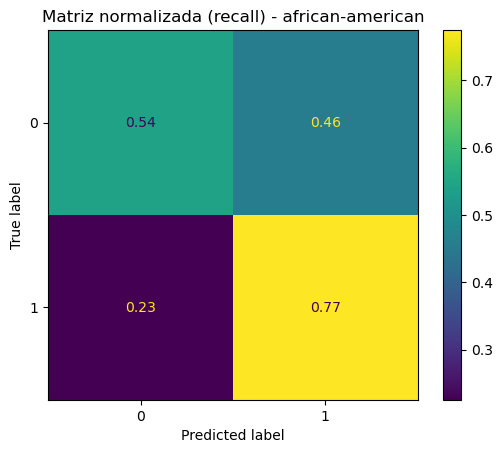


=== Raza: hispanic ===


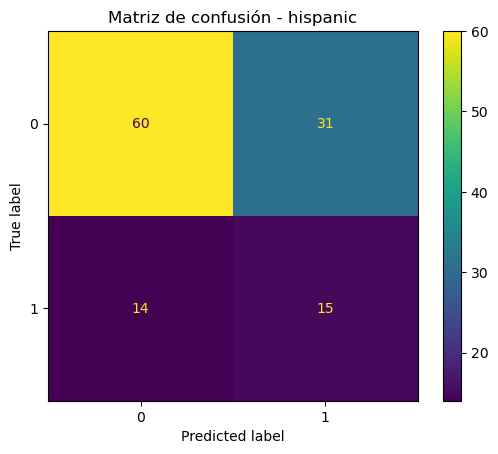

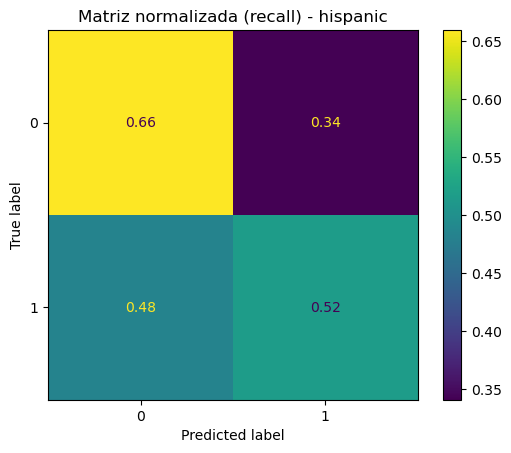


=== Raza: caucasian ===


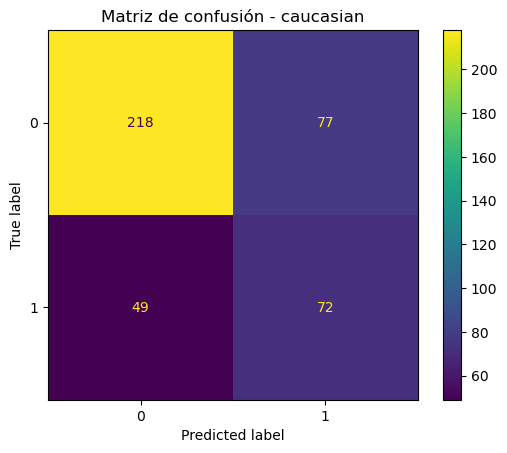

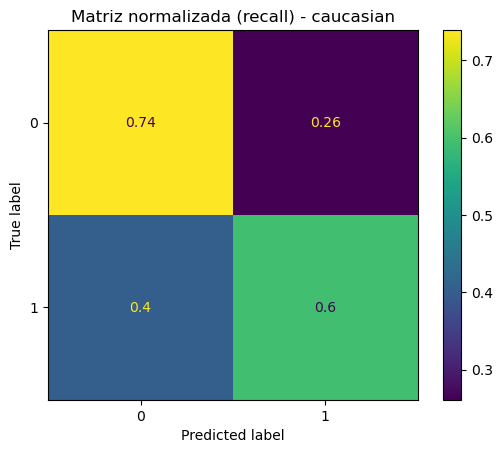

In [ ]:
X2 = df_sin_outliers.drop(columns=lista_columnas_dropear)
y2 = df_sin_outliers['two_year_recid']

X2_train, X2_test, y2_train, y2_test= train_test_split(X2, y2, test_size = 0.2, random_state = 69, stratify = y2)

model2 = LogisticRegression(max_iter=1000, penalty='l1', solver='liblinear', class_weight='balanced')

model2.fit(X2_train, y2_train)

y2_proba = model2.predict_proba(X2_test)[:,1]
y2_pred = (y2_proba >= 0.495).astype(int)

print("\nReporte de clasificación:")
print(classification_report(y2_test, y2_pred))
print("ROC AUC:", roc_auc_score(y2_test, y2_proba))

coeficientes = pd.DataFrame({
    'Variable': X2.columns,
    'Coeficiente': model2.coef_[0]
})

print(coeficientes)

print("Matriz de confusión:")
disp = ConfusionMatrixDisplay(confusion_matrix(y2_test, y2_pred))
disp.plot()
print("\n")
disp = ConfusionMatrixDisplay(confusion_matrix(y2_test, y2_pred, normalize= "all"))
disp.plot()
disp = ConfusionMatrixDisplay(confusion_matrix(y2_test, y2_pred, normalize= "true"))
disp.plot()
plt.show()
print("\n")
print("Reporte de clasificación:")
print(classification_report(y2_test, y2_pred))
print("ROC AUC:", roc_auc_score(y2_test, y2_proba))


race_test = df_sin_outliers.loc[X2_test.index, 'race']

razas = race_test.unique()

#generate confusion matrices by race

for raza in razas:
    idx = race_test == raza
    
    y_true_r = y2_test[idx]
    y_pred_r = y2_pred[idx]
    
    print(f"\n=== Raza: {raza} ===")
    
    cm = confusion_matrix(y_true_r, y_pred_r)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"Matriz de confusión - {raza}")
    plt.show()
    
    cm_norm = confusion_matrix(y_true_r, y_pred_r, normalize='true')
    disp = ConfusionMatrixDisplay(cm_norm)
    disp.plot()
    plt.title(f"Matriz normalizada (recall) - {raza}")
    plt.show()

Matriz de confusión:




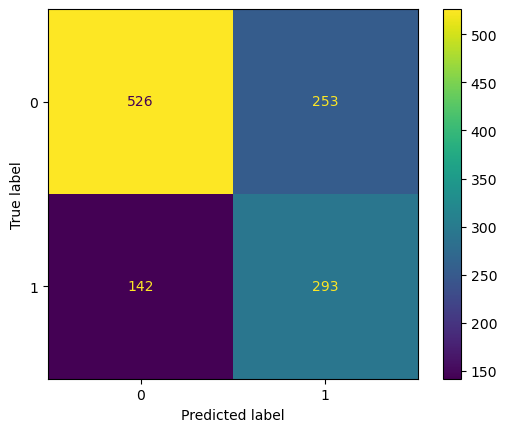

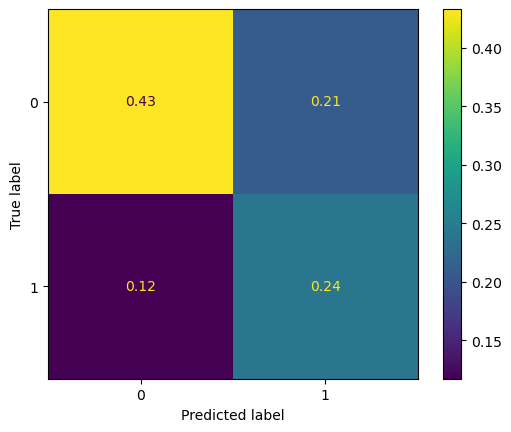

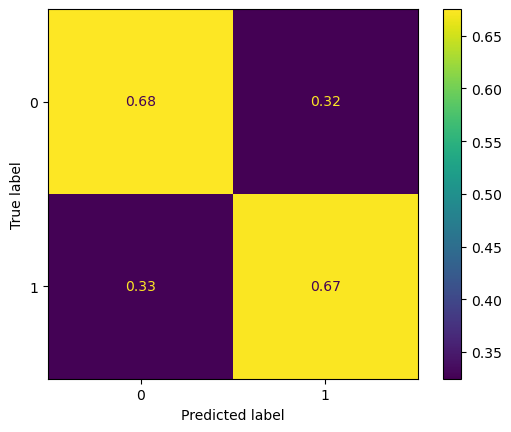



Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.79      0.68      0.73       779
           1       0.54      0.67      0.60       435

    accuracy                           0.67      1214
   macro avg       0.66      0.67      0.66      1214
weighted avg       0.70      0.67      0.68      1214

ROC AUC: 0.7400174110634028

=== Raza: other ===


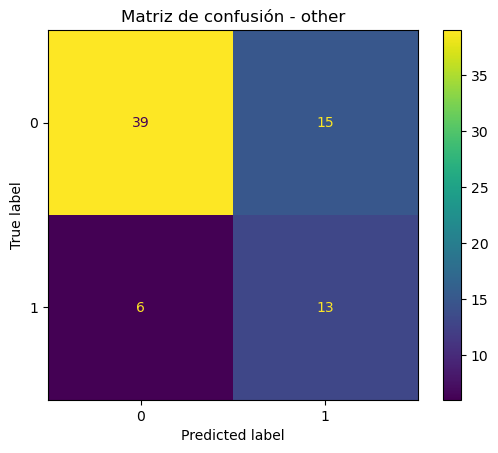

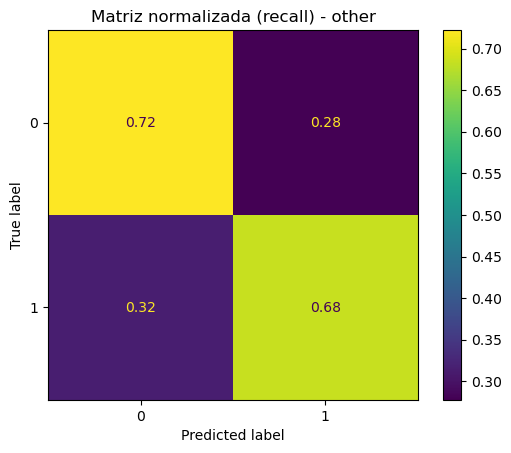


=== Raza: african-american ===


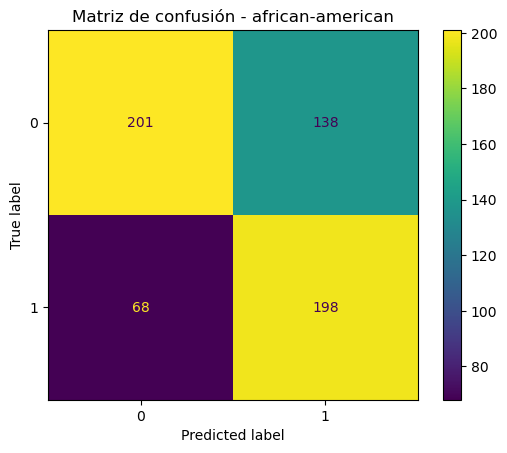

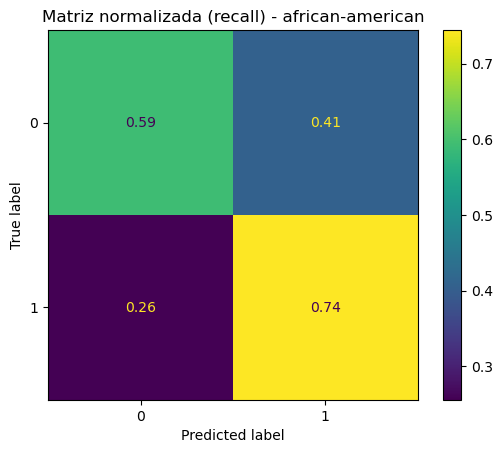


=== Raza: hispanic ===


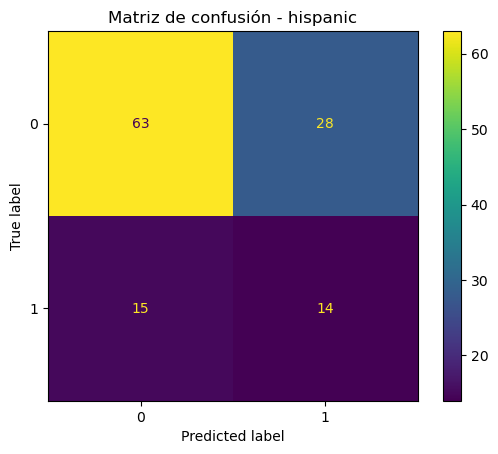

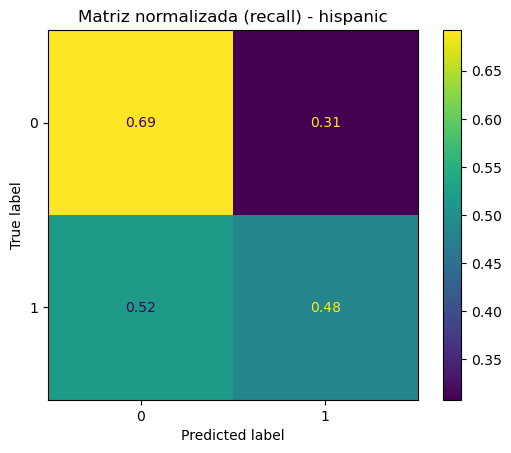


=== Raza: caucasian ===


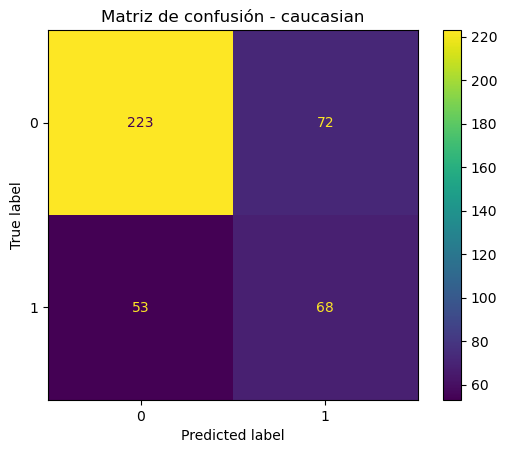

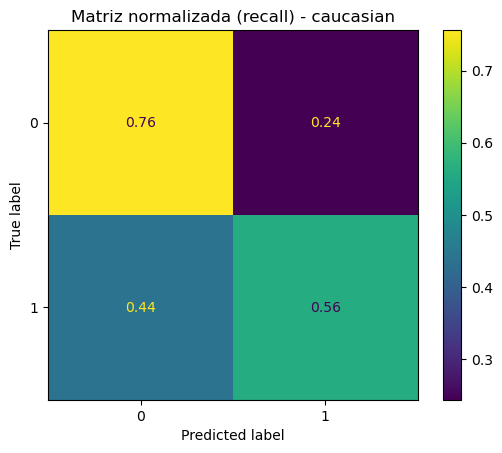

In [13]:
model2 = BaggingClassifier(
    estimator=LogisticRegression(penalty='l1', solver='liblinear'),
    n_estimators=10
)

model2.fit(X2_train, y2_train)

y2_proba = model2.predict_proba(X2_test)[:,1]
y2_pred = (y2_proba >= 0.37).astype(int)


print("Matriz de confusión:")
disp = ConfusionMatrixDisplay(confusion_matrix(y2_test, y2_pred))
disp.plot()
print("\n")
disp = ConfusionMatrixDisplay(confusion_matrix(y2_test, y2_pred, normalize= "all"))
disp.plot()
disp = ConfusionMatrixDisplay(confusion_matrix(y2_test, y2_pred, normalize= "true"))
disp.plot()
plt.show()
print("\n")
print("Reporte de clasificación:")
print(classification_report(y2_test, y2_pred))
print("ROC AUC:", roc_auc_score(y2_test, y2_proba))

#generate confusion matrices by race

for raza in razas:
    idx = race_test == raza
    
    y_true_r = y2_test[idx]
    y_pred_r = y2_pred[idx]
    
    print(f"\n=== Raza: {raza} ===")
    
    cm = confusion_matrix(y_true_r, y_pred_r)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"Matriz de confusión - {raza}")
    plt.show()
    
    cm_norm = confusion_matrix(y_true_r, y_pred_r, normalize='true')
    disp = ConfusionMatrixDisplay(cm_norm)
    disp.plot()
    plt.title(f"Matriz normalizada (recall) - {raza}")
    plt.show()

#### Test #4

In [11]:
lista_columnas_dropear = ['two_year_recid','person_id', 'decile_score', 'rawscore', 'v_decile_score', 'is_recid', 'is_violent_recid', 'maritalstatus', 'race', 'adult_priors_freq',
       'adult_priors_freq_3', 'maritalstatus_other', 'maritalstatus_separated', 'maritalstatus_significant other', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'sex', 'total_priors_count',
       'log_juv_priors_count', 'log_adult_priors_count', "adult_priors_count", 'maritalstatus_other', 'maritalstatus_separated', 'maritalstatus_significant other', 'age_cat']


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.79      0.68      0.73       779
           1       0.54      0.68      0.60       435

    accuracy                           0.68      1214
   macro avg       0.66      0.68      0.66      1214
weighted avg       0.70      0.68      0.68      1214

ROC AUC: 0.7310359582724684
               Variable  Coeficiente
0                   age    -0.029489
1      juv_priors_count     0.365851
2       c_charge_degree    -0.169645
3            is_violent    -0.309708
4               is_drug    -0.081655
5           is_property    -0.162228
6              is_fraud    -0.266954
7             is_weapon    -0.091537
8            is_traffic    -0.344577
9             is_sexual    -0.019194
10   is_public_disorder     0.000000
11   is_justice_related     0.000000
12            no_charge    -0.194244
13  adult_priors_freq_2    10.401576
Matriz de confusión:




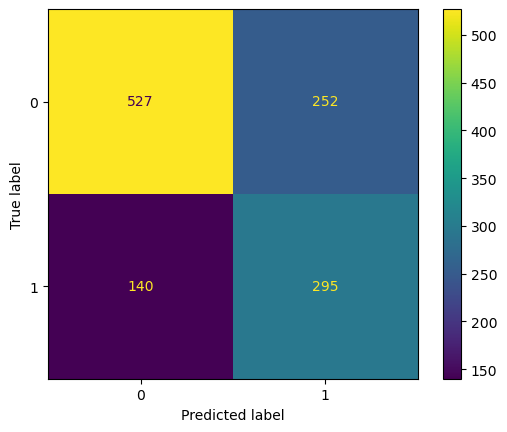

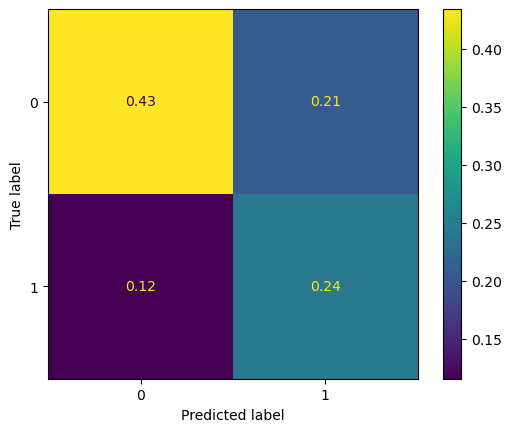

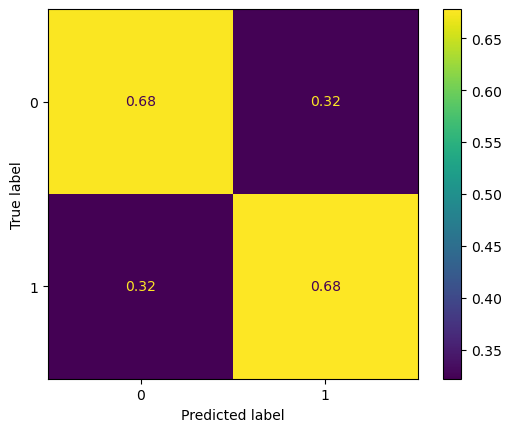



Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.79      0.68      0.73       779
           1       0.54      0.68      0.60       435

    accuracy                           0.68      1214
   macro avg       0.66      0.68      0.66      1214
weighted avg       0.70      0.68      0.68      1214

ROC AUC: 0.7310359582724684


In [ ]:
X3 = df_sin_outliers.drop(columns=lista_columnas_dropear)
y3 = df_sin_outliers['two_year_recid']

X3_train, X3_test, y3_train, y3_test= train_test_split(X3, y3, test_size = 0.2, random_state = 69, stratify = y3)

model3 = LogisticRegression(max_iter=1000, penalty='l1', solver='liblinear', class_weight = 'balanced')

model3.fit(X3_train, y3_train)

y3_proba = model3.predict_proba(X3_test)[:,1]
y3_pred = (y3_proba >= 0.505).astype(int)


print("\nReporte de clasificación:")
print(classification_report(y3_test, y3_pred))
print("ROC AUC:", roc_auc_score(y3_test, y3_proba))

coeficientes = pd.DataFrame({
    'Variable': X3.columns,
    'Coeficiente': model3.coef_[0]
})

print(coeficientes)


print("Matriz de confusión:")
disp = ConfusionMatrixDisplay(confusion_matrix(y3_test, y3_pred))
disp.plot()
print("\n")
disp = ConfusionMatrixDisplay(confusion_matrix(y3_test, y3_pred, normalize= "all"))
disp.plot()
disp = ConfusionMatrixDisplay(confusion_matrix(y3_test, y3_pred, normalize= "true"))
disp.plot()
plt.show()
print("\n")
print("Reporte de clasificación:")
print(classification_report(y3_test, y3_pred))
print("ROC AUC:", roc_auc_score(y3_test, y3_proba))

#generate confusion matrices by race

for raza in razas:
    idx = race_test == raza
    
    y_true_r = y3_test[idx]
    y_pred_r = y3_pred[idx]
    
    print(f"\n=== Raza: {raza} ===")
    
    cm = confusion_matrix(y_true_r, y_pred_r)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"Matriz de confusión - {raza}")
    plt.show()
    
    cm_norm = confusion_matrix(y_true_r, y_pred_r, normalize='true')
    disp = ConfusionMatrixDisplay(cm_norm)
    disp.plot()
    plt.title(f"Matriz normalizada (recall) - {raza}")
    plt.show()

Matriz de confusión:




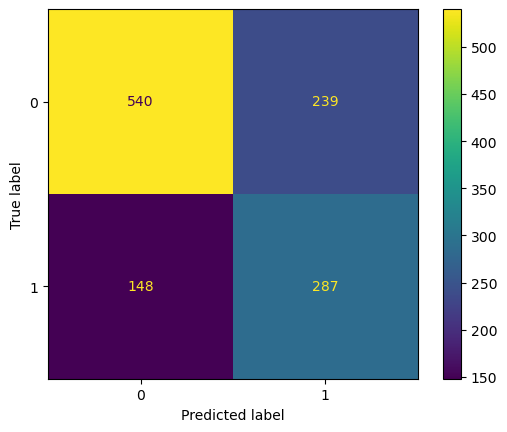

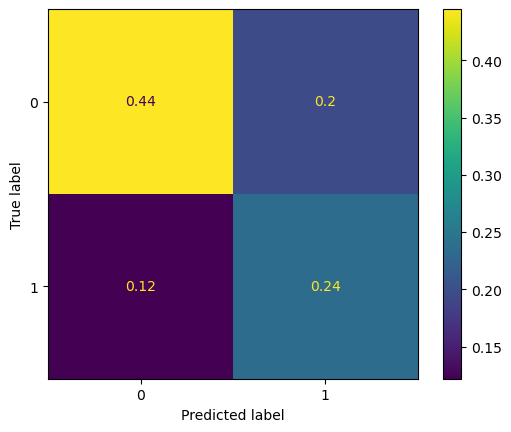

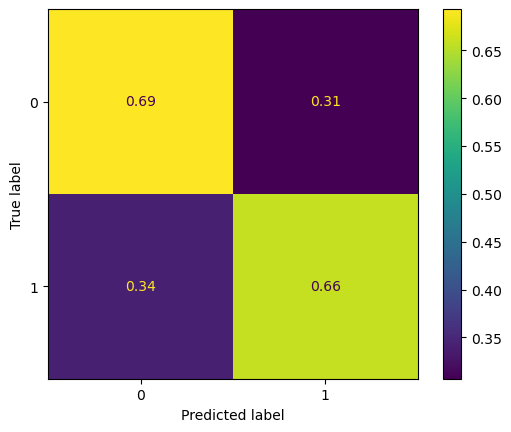



Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.78      0.69      0.74       779
           1       0.55      0.66      0.60       435

    accuracy                           0.68      1214
   macro avg       0.67      0.68      0.67      1214
weighted avg       0.70      0.68      0.69      1214

ROC AUC: 0.7271214200345271

=== Raza: other ===


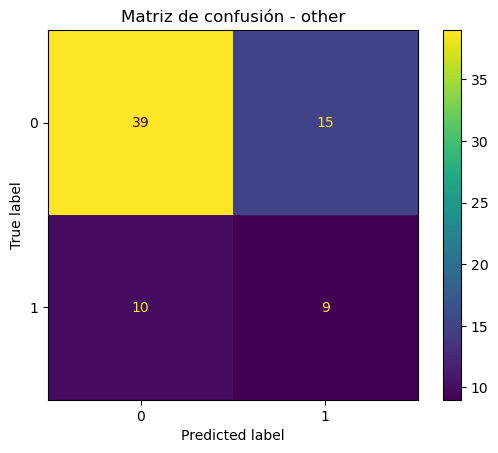

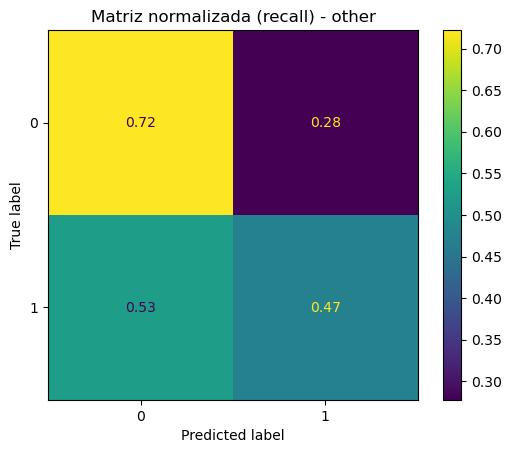


=== Raza: african-american ===


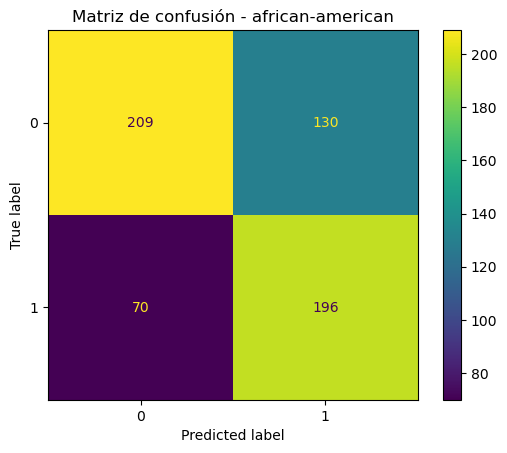

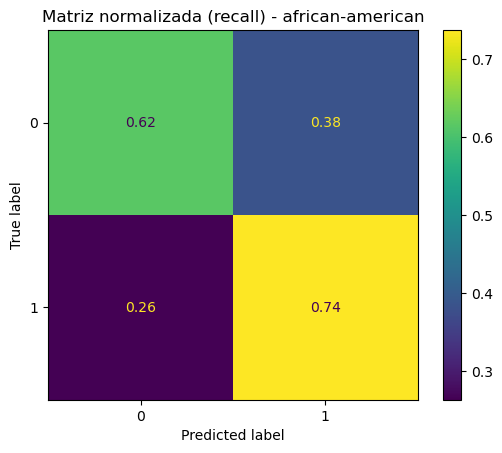


=== Raza: hispanic ===


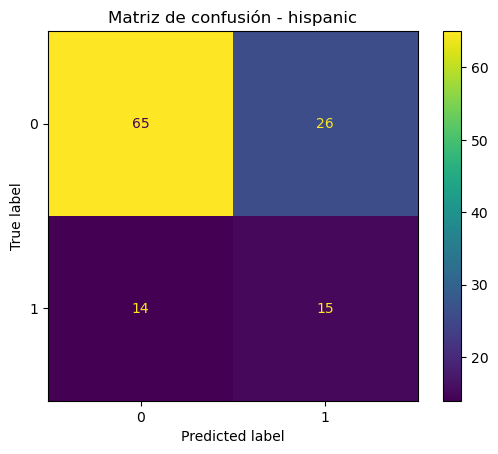

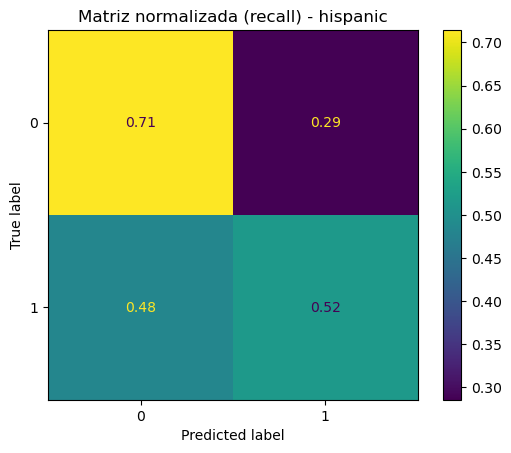


=== Raza: caucasian ===


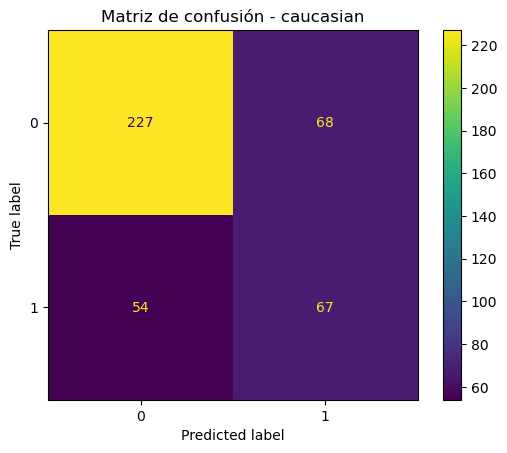

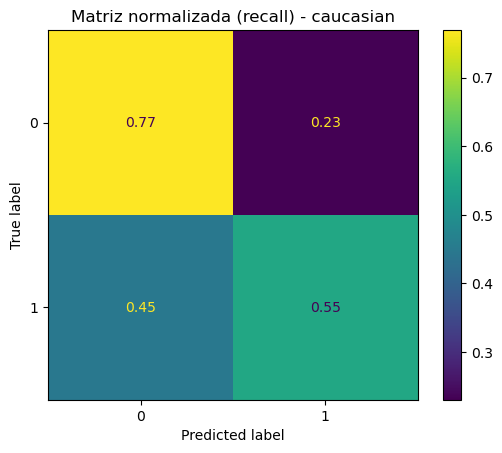

In [15]:
model3 = BaggingClassifier(
    estimator=LogisticRegression(penalty='l1', solver='liblinear'),
    n_estimators=10
)

model3.fit(X3_train, y3_train)

y3_proba = model3.predict_proba(X3_test)[:,1]
y3_pred = (y3_proba >= 0.37).astype(int)


print("Matriz de confusión:")
disp = ConfusionMatrixDisplay(confusion_matrix(y3_test, y3_pred))
disp.plot()
print("\n")
disp = ConfusionMatrixDisplay(confusion_matrix(y3_test, y3_pred, normalize= "all"))
disp.plot()
disp = ConfusionMatrixDisplay(confusion_matrix(y3_test, y3_pred, normalize= "true"))
disp.plot()
plt.show()
print("\n")
print("Reporte de clasificación:")
print(classification_report(y3_test, y3_pred))
print("ROC AUC:", roc_auc_score(y3_test, y3_proba))

race_test = df_sin_outliers.loc[X3_test.index, 'race']

razas = race_test.unique()

#generate confusion matrices by race

for raza in razas:
    idx = race_test == raza
    
    y_true_r = y3_test[idx]
    y_pred_r = y3_pred[idx]
    
    print(f"\n=== Raza: {raza} ===")
    
    cm = confusion_matrix(y_true_r, y_pred_r)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"Matriz de confusión - {raza}")
    plt.show()
    
    cm_norm = confusion_matrix(y_true_r, y_pred_r, normalize='true')
    disp = ConfusionMatrixDisplay(cm_norm)
    disp.plot()
    plt.title(f"Matriz normalizada (recall) - {raza}")
    plt.show()

#### Test #5

In [19]:
lista_columnas_dropear = ['two_year_recid','person_id', 'decile_score', 'rawscore', 'v_decile_score', 'is_recid', 'is_violent_recid', 'maritalstatus', 'race', 'adult_priors_freq',
       'adult_priors_freq_3', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'sex', 'total_priors_count',
       'log_juv_priors_count', 'log_adult_priors_count', 'adult_priors_count', 'maritalstatus_other', 'maritalstatus_separated', 'maritalstatus_significant other', 'age_cat']


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.78      0.68      0.73       779
           1       0.54      0.66      0.59       435

    accuracy                           0.67      1214
   macro avg       0.66      0.67      0.66      1214
weighted avg       0.70      0.67      0.68      1214

ROC AUC: 0.7324052351231316
               Variable  Coeficiente
0                   age    -0.028375
1      juv_priors_count     0.362080
2       c_charge_degree    -0.202762
3            is_violent    -0.229296
4               is_drug     0.000000
5           is_property    -0.136923
6              is_fraud    -0.248278
7             is_weapon    -0.156913
8            is_traffic    -0.294834
9             is_sexual    -0.099889
10   is_public_disorder     0.000000
11   is_justice_related    -0.000401
12            no_charge    -0.180876
13  adult_priors_freq_2    11.110300
Matriz de confusión:




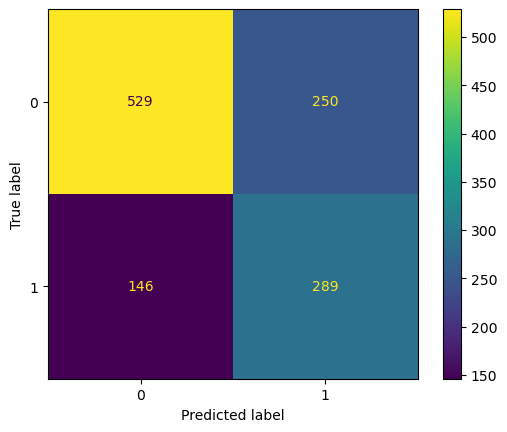

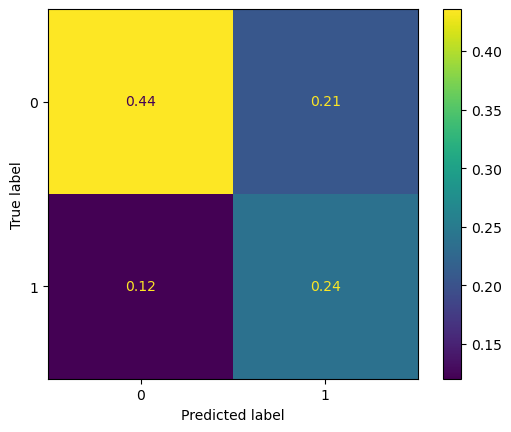

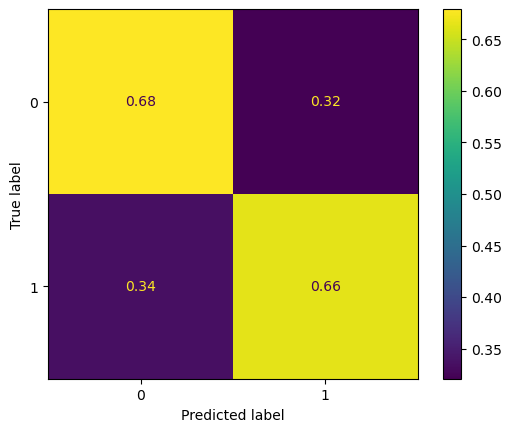




=== Raza: other ===


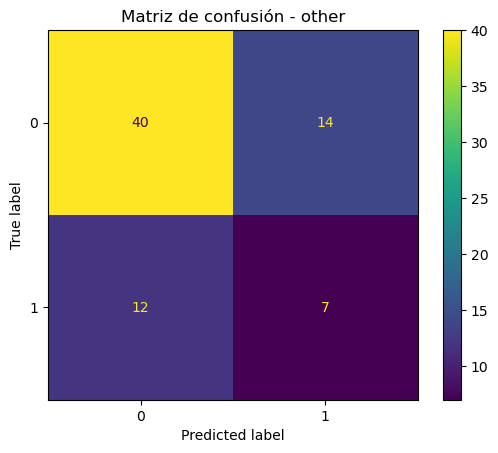

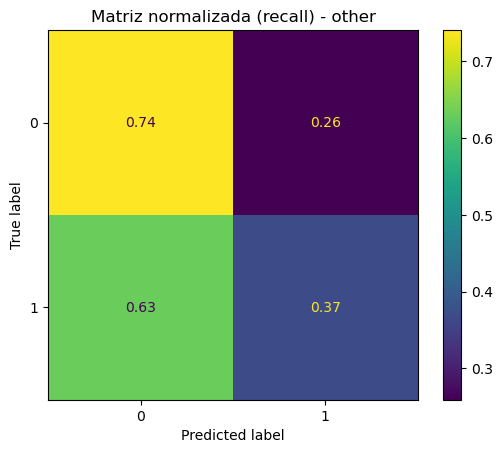


=== Raza: african-american ===


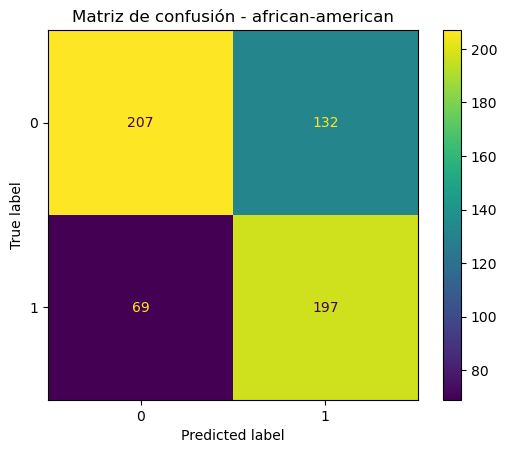

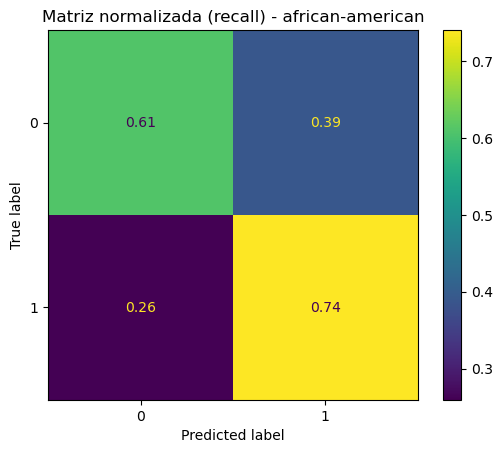


=== Raza: hispanic ===


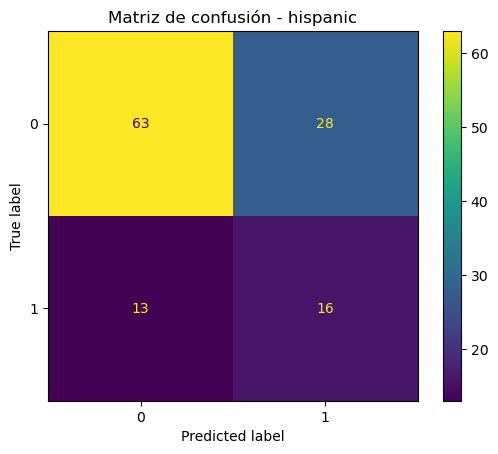

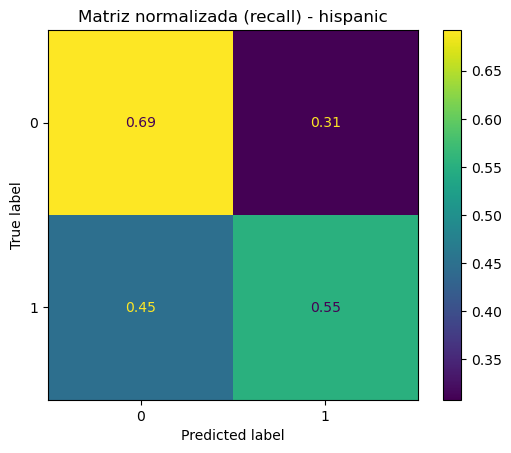


=== Raza: caucasian ===


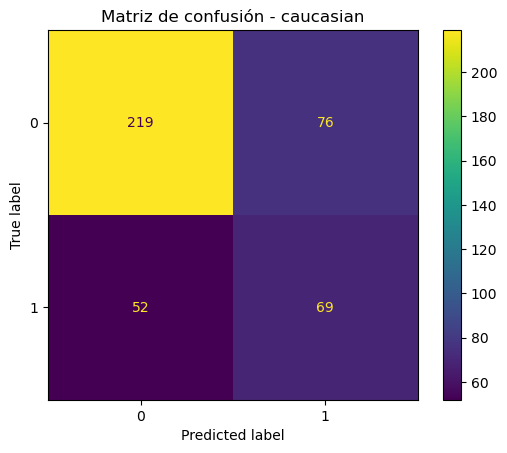

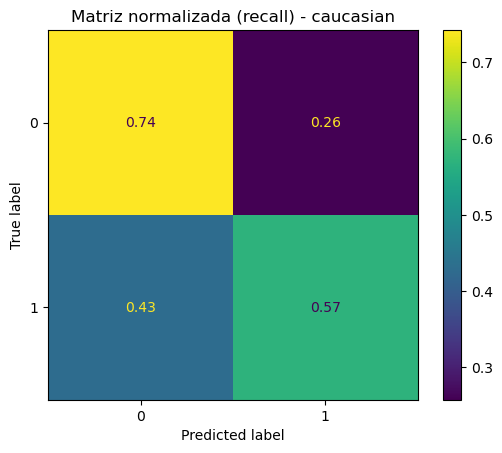

In [21]:
X = df_sin_outliers.drop(columns=lista_columnas_dropear)
y = df_sin_outliers['two_year_recid']
race = df_sin_outliers['race']

X_train, X_test, y_train, y_test, race_train, race_test= train_test_split(X, y, race, test_size = 0.2, random_state = 69, stratify = y)

#reweighting

#weights by class

conteo = y_train.value_counts()
total = len(y_train)

peso_0 = total / (2 * conteo[0])
peso_1 = total / (2 * conteo[1])

w_class = y_train.map({
    0: peso_0,
    1: peso_1
})

#weights by race

dist_raza = race_train.value_counts(normalize=True)

peso_raza = {r: 1 / np.sqrt(dist_raza[r]) for r in dist_raza.index}

w_race = race_train.map(peso_raza)

#final weights

w_train = w_class * w_race

#model

model = LogisticRegression(max_iter=1000, penalty='l1', solver='liblinear')

model.fit(X_train, y_train, sample_weight=w_train)

y_proba = model.predict_proba(X_test)[:,1]
y_pred = (y_proba >= 0.5).astype(int)


print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': model.coef_[0]
})

print(coeficientes)

print("Matriz de confusión:")
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred))
disp.plot()
print("\n")
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize= "all"))
disp.plot()
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize= "true"))
disp.plot()
plt.show()
print("\n")


race_test = df_sin_outliers.loc[X_test.index, 'race']

razas = race_test.unique()

#generate confusion matrices by race

for raza in razas:
    idx = race_test == raza
    
    y_true_r = y_test[idx]
    y_pred_r = y_pred[idx]
    
    print(f"\n=== Raza: {raza} ===")
    
    cm = confusion_matrix(y_true_r, y_pred_r)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"Matriz de confusión - {raza}")
    plt.show()

    cm_norm = confusion_matrix(y_true_r, y_pred_r, normalize='true')
    disp = ConfusionMatrixDisplay(cm_norm)
    disp.plot()
    plt.title(f"Matriz normalizada (recall) - {raza}")
    plt.show()

### Decision tree models

### Adversarial model

### Fairness model

## Final model

## Modelo v.2.0

### Threshold por raza - con reweighting


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.79      0.65      0.72       779
           1       0.53      0.69      0.60       435

    accuracy                           0.67      1214
   macro avg       0.66      0.67      0.66      1214
weighted avg       0.70      0.67      0.67      1214

ROC AUC: 0.7323668717630916

Coeficientes:
               Variable  Coeficiente
13  adult_priors_freq_2    11.108333
1      juv_priors_count     0.361963
10   is_public_disorder     0.000000
4               is_drug     0.000000
11   is_justice_related    -0.000628
0                   age    -0.028402
9             is_sexual    -0.099998
5           is_property    -0.137246
7             is_weapon    -0.157001
12            no_charge    -0.180953
2       c_charge_degree    -0.202894
3            is_violent    -0.229568
6              is_fraud    -0.248654
8            is_traffic    -0.295038


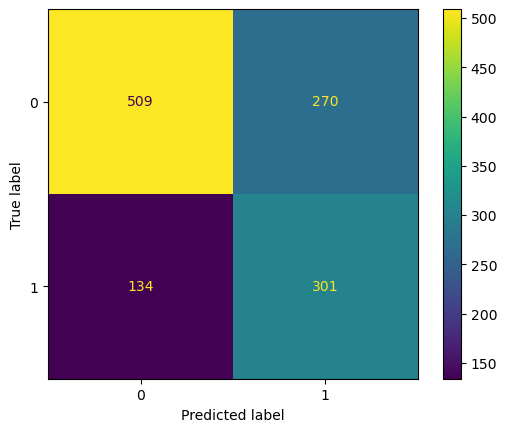

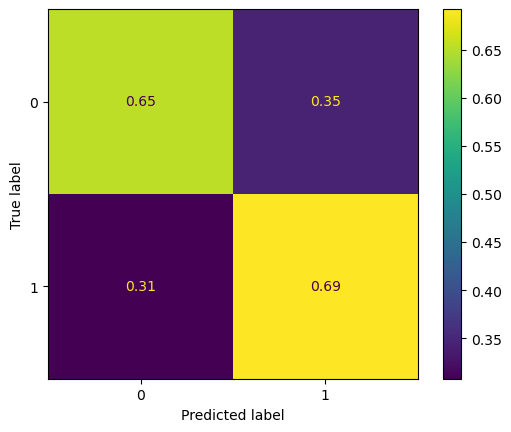


=== Raza: other ===


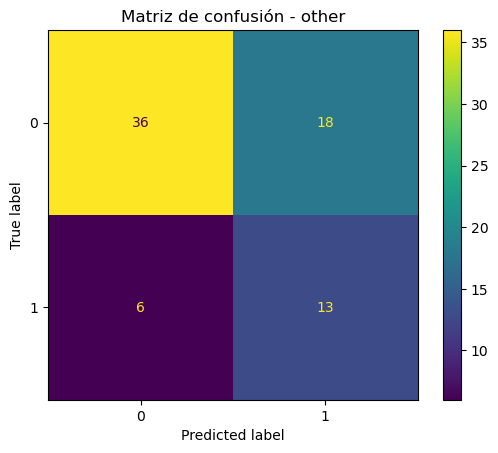

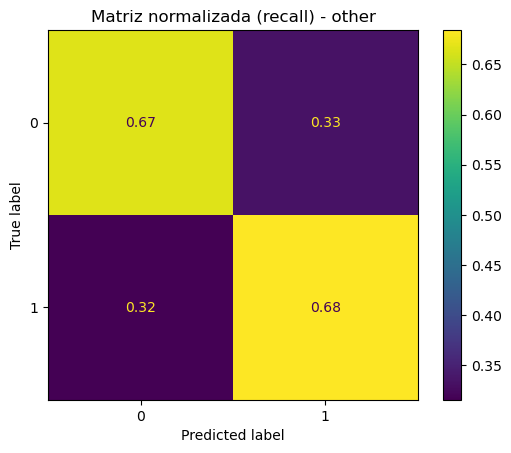


=== Raza: african-american ===


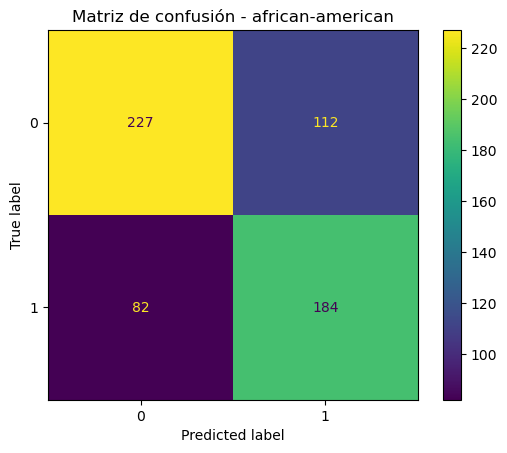

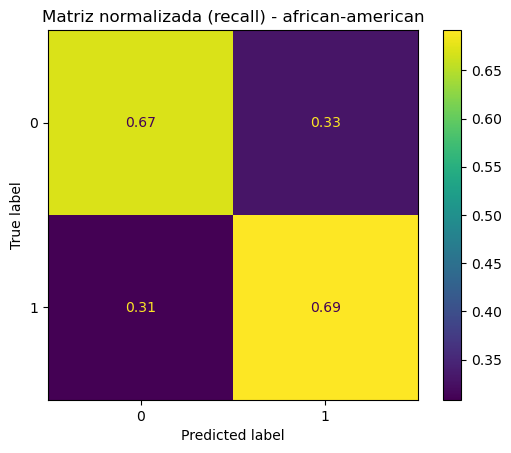


=== Raza: hispanic ===


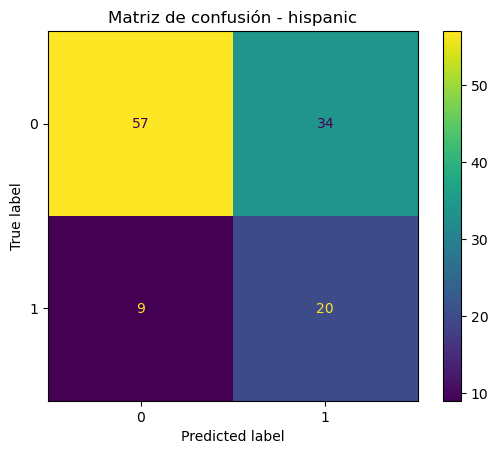

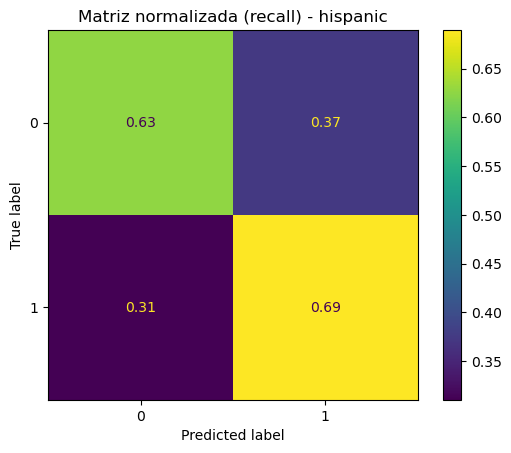


=== Raza: caucasian ===


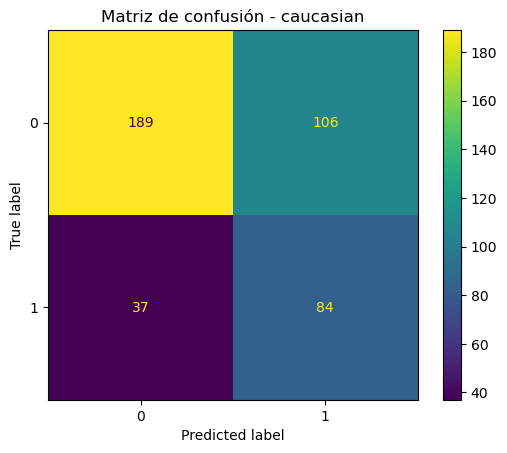

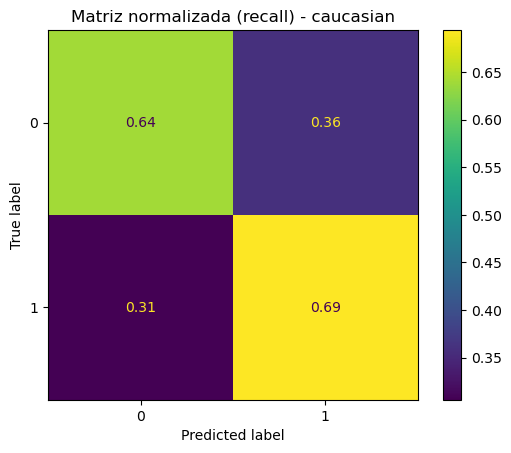

In [28]:
# -------------------------
# 1. SPLIT
# -------------------------
X_train, X_test, y_train, y_test, race_train, race_test = train_test_split(
    X, y, race,
    test_size=0.2,
    random_state=69,
    stratify=y
)

# -------------------------
# 2. PESOS POR CLASE
# -------------------------
conteo = y_train.value_counts()
total = len(y_train)

peso_0 = total / (2 * conteo[0])
peso_1 = total / (2 * conteo[1])

w_class = y_train.map({0: peso_0, 1: peso_1})

# -------------------------
# 3. PESOS POR RAZA
# -------------------------
dist_raza = race_train.value_counts(normalize=True)

peso_raza = {r: 1 / np.sqrt(dist_raza[r]) for r in dist_raza.index}
w_race = race_train.map(peso_raza)

# -------------------------
# 4. PESO FINAL
# -------------------------
w_train = w_class * w_race

# -------------------------
# 5. MODELO
# -------------------------
model = LogisticRegression(max_iter=1000, penalty='l1', solver='liblinear')
model.fit(X_train, y_train, sample_weight=w_train)

# -------------------------
# 6. PROBABILIDADES
# -------------------------
y_proba = model.predict_proba(X_test)[:, 1]

# -------------------------
# 7. DATAFRAME EVALUACIÓN
# -------------------------
df_eval = pd.DataFrame({
    'y_true': y_test,
    'race': race_test
})

df_eval['y_score'] = y_proba

# -------------------------
# 8. THRESHOLD POR RAZA
# -------------------------
thresholds = {
    'african-american': 0.52,
    'caucasian': 0.42,
    'hispanic': 0.44,
    'other': 0.45
}

def aplicar_threshold(row):
    return int(row['y_score'] >= thresholds[row['race']])

df_eval['y_pred'] = df_eval.apply(aplicar_threshold, axis=1)
y_pred = df_eval['y_pred'].values

# -------------------------
# 9. RESULTADOS GLOBALES
# -------------------------

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

print("ROC AUC:", roc_auc_score(y_test, y_proba))

# -------------------------
# 10. COEFICIENTES
# -------------------------
coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': model.coef_[0]
})

print("\nCoeficientes:")
print(coeficientes.sort_values(by='Coeficiente', ascending=False))

# -------------------------
# 11. VISUALIZACIÓN GLOBAL
# -------------------------
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, normalize="true")

plt.show()

# -------------------------
# 12. FAIRNESS POR RAZA
# -------------------------
for raza in razas:
    idx = race_test == raza
    
    y_true_r = y_test[idx]
    y_pred_r = y_pred[idx]
    
    print(f"\n=== Raza: {raza} ===")
    
    cm = confusion_matrix(y_true_r, y_pred_r)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"Matriz de confusión - {raza}")
    plt.show()
    
    # Normalizada (recall)
    cm_norm = confusion_matrix(y_true_r, y_pred_r, normalize='true')
    disp = ConfusionMatrixDisplay(cm_norm)
    disp.plot()
    plt.title(f"Matriz normalizada (recall) - {raza}")
    plt.show()

    # # FPR
    # fp = ((grupo['y_pred'] == 1) & (grupo['y_true'] == 0)).sum()
    # tn = ((grupo['y_pred'] == 0) & (grupo['y_true'] == 0)).sum()
    # fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    # # TPR
    # tp = ((grupo['y_pred'] == 1) & (grupo['y_true'] == 1)).sum()
    # fn = ((grupo['y_pred'] == 0) & (grupo['y_true'] == 1)).sum()
    # tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    # print(f"FPR: {fpr:.3f} | TPR: {tpr:.3f}")

### Modelo v.2.0 - Adversarial

In [29]:
# # -------------------------
# # 1. COPIA DATASET
# # -------------------------
# df_aif = df_sin_outliers.copy()

# race_original = df_sin_outliers['race']

# # -------------------------
# # 2. CREAR VARIABLE BINARIA DE RAZA
# # (elige el criterio que quieras)
# # -------------------------
# df_aif['race_binary'] = (df_aif['race'] == 'african-american').astype(int)

# # -------------------------
# # 3. ELIMINAR race original
# # -------------------------
# df_aif = df_aif.drop(columns=['race'])

# # -------------------------
# # 4. CONVERTIR TODO A NUMÉRICO
# # -------------------------
# df_aif = pd.get_dummies(df_aif, drop_first=True)

# # -------------------------
# # 5. SPLIT
# # -------------------------
# df_train, df_test, race_train_orig, race_test_orig = train_test_split(
#     df_aif,
#     race_original,
#     test_size=0.2,
#     random_state=69,
#     stratify=df_aif['two_year_recid']
# )

# # -------------------------
# # 6. CREAR DATASETS AIF360
# # -------------------------
# train_dataset = BinaryLabelDataset(
#     df=df_train,
#     label_names=['two_year_recid'],
#     protected_attribute_names=['race_binary']
# )

# test_dataset = BinaryLabelDataset(
#     df=df_test,
#     label_names=['two_year_recid'],
#     protected_attribute_names=['race_binary']
# )

# # -------------------------
# # 7. DEFINIR GRUPOS
# # -------------------------
# privileged_groups = [{'race_binary': 1}]
# unprivileged_groups = [{'race_binary': 0}]

# # -------------------------
# # 8. MODELO ADVERSARIAL
# # -------------------------

# import sys
# import tensorflow.compat.v1 as tf

# sys.modules['tensorflow'] = tf
# tf.disable_eager_execution()

# tf.compat.v1.disable_eager_execution()

# tf.compat.v1.reset_default_graph()

# sess = tf.compat.v1.Session()

# model_adv = AdversarialDebiasing(
#     privileged_groups=privileged_groups,
#     unprivileged_groups=unprivileged_groups,
#     scope_name='debiasing',
#     debias=True,
#     sess=sess
# )

# model_adv.fit(train_dataset)

# # -------------------------
# # 9. PREDICCIÓN
# # -------------------------
# pred_dataset = model_adv.predict(test_dataset)

# y_pred_adv = pred_dataset.labels.ravel()
# y_true = test_dataset.labels.ravel()
# y_scores_adv = pred_dataset.scores.ravel()

# print("Matriz de confusión:")
# print(confusion_matrix(y_true, y_pred_adv))

# print("\nReporte de clasificación:")
# print(classification_report(y_true, y_pred_adv))

# print("ROC AUC:", roc_auc_score(y_true, y_scores_adv))

# df_eval = df_test.copy()
# df_eval['y_true'] = y_true
# df_eval['y_pred'] = y_pred_adv
# df_eval['race'] = race_test_orig.values

# # FPR por raza
# for r in df_eval['race'].unique():
#     grupo = df_eval[df_eval['race'] == r]
    
#     fp = ((grupo['y_pred'] == 1) & (grupo['y_true'] == 0)).sum()
#     tn = ((grupo['y_pred'] == 0) & (grupo['y_true'] == 0)).sum()
    
#     fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
#     print(f"Race {r} - FPR: {fpr:.3f}")

### FairLearn

In [30]:
# # -------------------------
# # 1. Datos
# # -------------------------
# X = df_sin_outliers.drop(columns=lista_columnas_dropear)
# y = df_sin_outliers['two_year_recid']
# race = df_sin_outliers['race']

# X_train, X_test, y_train, y_test, race_train, race_test = train_test_split(
#     X, y, race,
#     test_size=0.2,
#     random_state=69,
#     stratify=y
# )

# # -------------------------
# # 2. Modelo base (CORREGIDO)
# # -------------------------
# base_model = LogisticRegression(
#     max_iter=1000,
#     penalty='l2',   # 馃敟 cambio importante
#     solver='lbfgs'
# )

# # -------------------------
# # 3. Fairlearn
# # -------------------------
# fair_model = ExponentiatedGradient(
#     estimator=base_model,
#     constraints=DemographicParity(),
#     eps=0.1
# )

# fair_model.fit(X_train, y_train, sensitive_features=race_train)

# # -------------------------
# # 4. Probabilidades
# # -------------------------
# y_scores = fair_model._pmf_predict(X_test)[:, 1]

# # 馃攳 DEBUG CLAVE
# print("Distribuci贸n de probabilidades:")
# print("min:", y_scores.min())
# print("max:", y_scores.max())
# print("mean:", y_scores.mean())

# # -------------------------
# # 5. Threshold tuning
# # -------------------------
# for t in [0.2, 0.3, 0.4, 0.5]:
#     y_pred_tmp = (y_scores >= t).astype(int)
#     print(f"\nThreshold {t}")
#     print(confusion_matrix(y_test, y_pred_tmp))

# # 馃憠 usa uno razonable
# threshold = 0.3
# y_pred_fair = (y_scores >= threshold).astype(int)

# # -------------------------
# # 6. Coeficientes
# # -------------------------
# best_model = fair_model.predictors_[np.argmax(fair_model.weights_)]

# coeficientes = pd.DataFrame({
#     'Variable': X.columns,
#     'Coeficiente': best_model.coef_[0]
# })

# print(coeficientes.sort_values(by='Coeficiente', ascending=False))

# # -------------------------
# # 7. Evaluaci贸n global
# # -------------------------
# print("\nMatriz de confusi贸n:")
# disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_fair))
# disp.plot()

# plt.show()

# print("\nReporte de clasificaci贸n:")
# print(classification_report(y_test, y_pred_fair))

# # -------------------------
# # 8. Evaluaci贸n por raza
# # -------------------------
# y_pred_series = pd.Series(y_pred_fair, index=y_test.index)

# for raza in race_test.unique():
#     idx = race_test == raza
    
#     y_true_r = y_test.loc[idx]
#     y_pred_r = y_pred_series.loc[idx]
    
#     print(f"\n=== Raza: {raza} ===")
    
#     cm = confusion_matrix(y_true_r, y_pred_r)
#     ConfusionMatrixDisplay(cm).plot()
#     plt.title(f"Matriz - {raza}")
#     plt.show()
    
#     cm_norm = confusion_matrix(y_true_r, y_pred_r, normalize='true')
#     ConfusionMatrixDisplay(cm_norm).plot()
#     plt.title(f"Recall - {raza}")
#     plt.show()

### Threshold por raza - sin reweighting

In [31]:
lista_columnas_dropear = ['two_year_recid', 'decile_score', 'rawscore', 'v_decile_score', 'is_recid', 'is_violent_recid', 'maritalstatus', 'race', 'adult_priors_freq',
       'adult_priors_freq_3', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'total_priors_count',
       'log_juv_priors_count', 'log_adult_priors_count', "adult_priors_count", 'maritalstatus_other', 'maritalstatus_separated', 'maritalstatus_significant other', 'sex', 'age_cat']

este es el bueno

In [32]:
from sklearn.preprocessing import StandardScaler

features_num = ['age', 'juv_priors_count', 'adult_priors_freq_2']
features_bin = ['is_public_disorder', 'is_justice_related', 'is_sexual', 'is_drug', 'is_weapon', 'is_property', 'c_charge_degree', 'no_charge', 'is_fraud', 'is_violent', 'is_traffic']

scaler = StandardScaler()
df_model_scaled = df_sin_outliers.copy()
df_model_scaled[features_num] = scaler.fit_transform(df_sin_outliers[features_num])



Coeficientes:
               Variable  Coeficiente
13  adult_priors_freq_2     0.676972
1      juv_priors_count     0.223406
10   is_public_disorder     0.000000
11   is_justice_related     0.000000
9             is_sexual    -0.014986
4               is_drug    -0.081506
7             is_weapon    -0.091046
5           is_property    -0.161650
2       c_charge_degree    -0.166817
12            no_charge    -0.198532
6              is_fraud    -0.266204
3            is_violent    -0.307221
8            is_traffic    -0.345212
0                   age    -0.357012

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.79      0.68      0.73       779
           1       0.54      0.68      0.60       435

    accuracy                           0.68      1214
   macro avg       0.67      0.68      0.67      1214
weighted avg       0.70      0.68      0.68      1214

ROC AUC: 0.7314933675652546


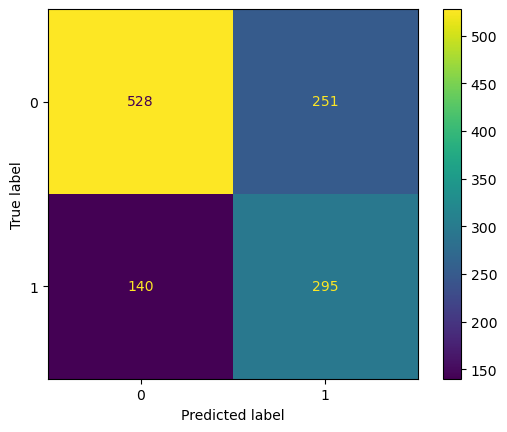

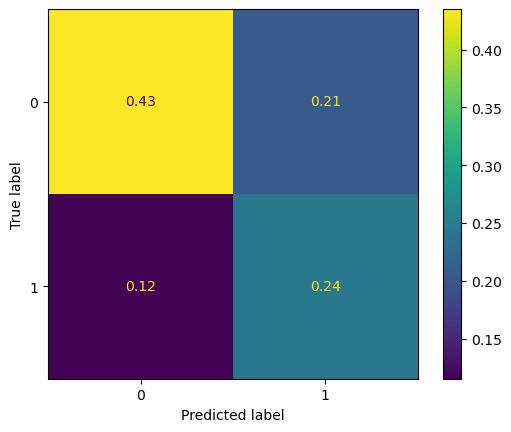

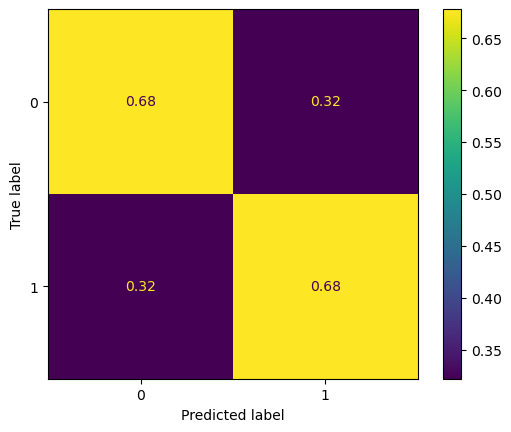


=== Raza: other ===


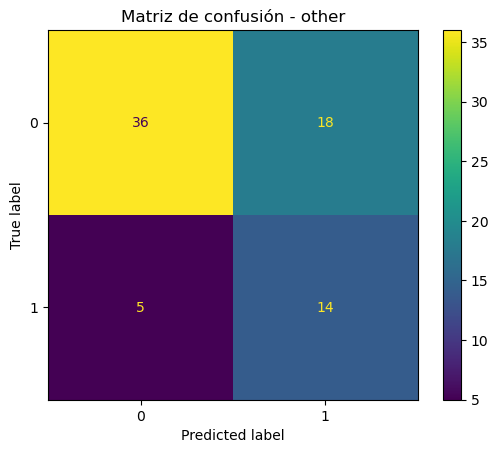

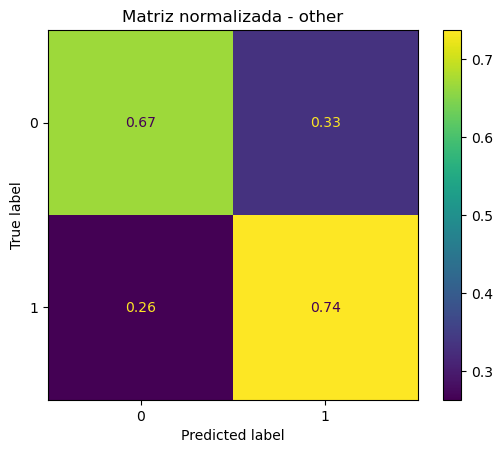

FPR: 0.333 | TPR: 0.737

=== Raza: african-american ===


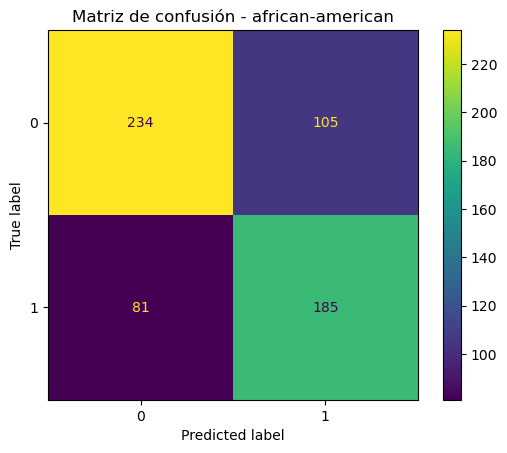

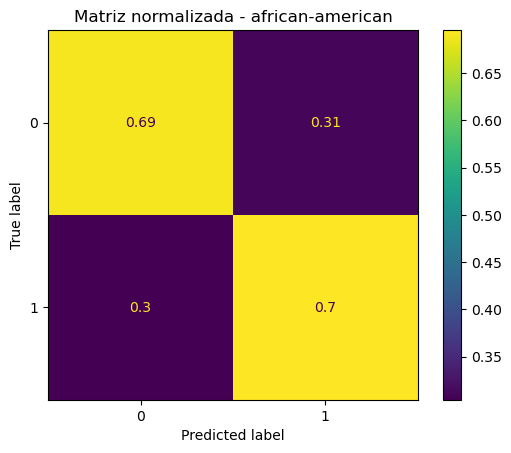

FPR: 0.310 | TPR: 0.695

=== Raza: hispanic ===


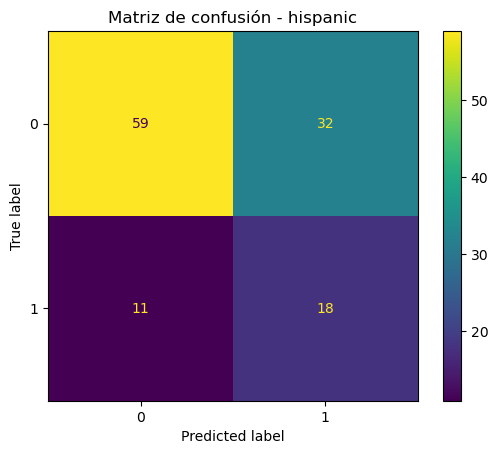

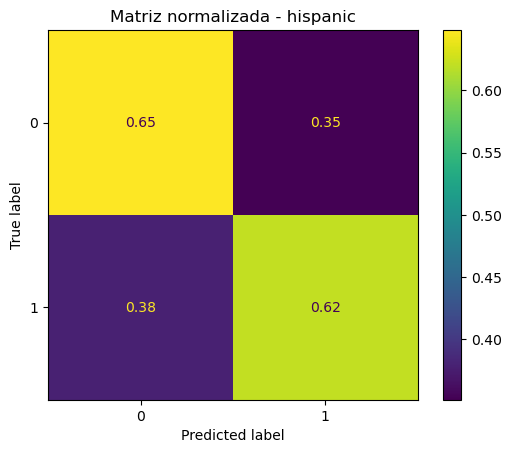

FPR: 0.352 | TPR: 0.621

=== Raza: caucasian ===


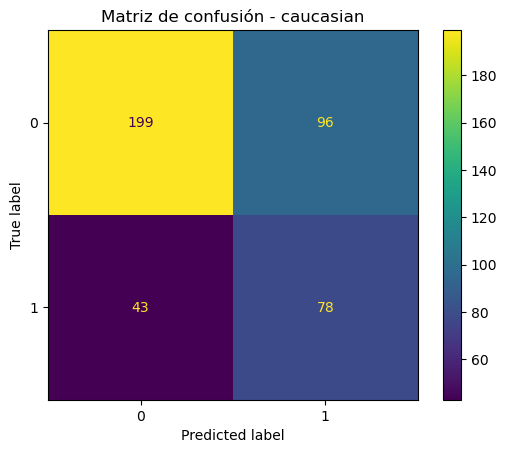

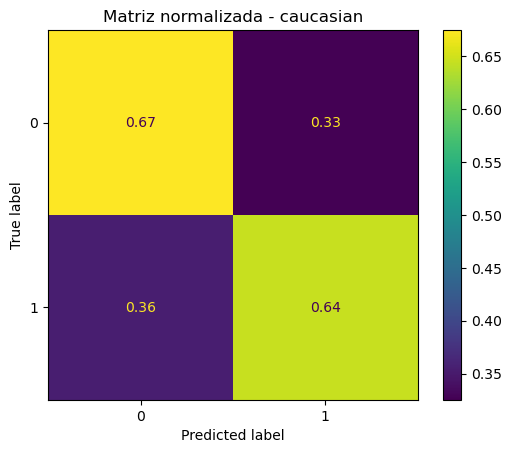

FPR: 0.325 | TPR: 0.645


In [33]:

# -------------------------
# 1. DATOS
# -------------------------
X = df_model_scaled.drop(columns=lista_columnas_dropear)
y = df_model_scaled['two_year_recid']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=69, stratify=y
)


person_id_test = X_test['person_id']

X_train = X_train.drop(columns=['person_id'])
X_test = X_test.drop(columns=['person_id'])

# -------------------------
# 2. MODELO
# -------------------------
model = LogisticRegression(
    max_iter=1000,
    penalty='l1',
    solver='liblinear',
    class_weight='balanced'
)

model.fit(X_train, y_train)

# -------------------------
# 3. PROBABILIDADES
# -------------------------
y_proba = pd.Series(
    model.predict_proba(X_test)[:, 1],
    index=X_test.index
)

# -------------------------
# 4. RAZA (para fairness)
# -------------------------
df_aux = df_sin_outliers.set_index('person_id')

race_test = df_aux.loc[person_id_test, 'race']
sex_test = df_aux.loc[person_id_test, 'sex']
age_cat_test = df_aux.loc[person_id_test, 'age_cat']

# -------------------------
# 5. DATAFRAME EVALUACIÓN
# -------------------------
df_eval = pd.DataFrame(index=X_test.index)

df_eval['person_id'] = person_id_test.values
df_eval['y_true'] = y_test.values
df_eval['race'] = race_test.values
df_eval['sex'] = sex_test.values
df_eval['age_cat'] = age_cat_test.values
df_eval['y_score'] = y_proba.values

# -------------------------
# 6. THRESHOLD POR RAZA
# -------------------------
thresholds = {
    'african-american': 0.53,
    'caucasian': 0.45,
    'hispanic': 0.46,
    'other': 0.45
}

def aplicar_threshold(row):
    return int(row['y_score'] >= thresholds[row['race']])

df_eval['y_pred'] = df_eval.apply(aplicar_threshold, axis=1)

y_pred = df_eval['y_pred'].values

# -------------------------
# 7. COEFICIENTES
# -------------------------
coeficientes = pd.DataFrame({
    'Variable': X_train.columns,
    'Coeficiente': model.coef_[0]
})

print("\nCoeficientes:")
print(coeficientes.sort_values(by='Coeficiente', ascending=False))

# -------------------------
# 8. EVALUACIÓN GLOBAL
# -------------------------

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

print("ROC AUC:", roc_auc_score(y_test, y_proba))

# -------------------------
# 9. VISUALIZACIÓN GLOBAL
# -------------------------
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred))
disp.plot()

disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize="all"))
disp.plot()

disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize="true"))
disp.plot()

plt.show()

# -------------------------
# 10. FAIRNESS POR RAZA
# -------------------------
razas = df_eval['race'].unique()

for raza in razas:
    grupo = df_eval[df_eval['race'] == raza]
    
    y_true_r = grupo['y_true']
    y_pred_r = grupo['y_pred']
    
    print(f"\n=== Raza: {raza} ===")
    
    # Matriz normal
    cm = confusion_matrix(y_true_r, y_pred_r)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"Matriz de confusión - {raza}")
    plt.show()
    
    # Matriz normalizada
    cm_norm = confusion_matrix(y_true_r, y_pred_r, normalize='true')
    disp = ConfusionMatrixDisplay(cm_norm)
    disp.plot()
    plt.title(f"Matriz normalizada - {raza}")
    plt.show()
    
    # 🔥 FPR
    fp = ((y_pred_r == 1) & (y_true_r == 0)).sum()
    tn = ((y_pred_r == 0) & (y_true_r == 0)).sum()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    # 🔥 TPR
    tp = ((y_pred_r == 1) & (y_true_r == 1)).sum()
    fn = ((y_pred_r == 0) & (y_true_r == 1)).sum()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    print(f"FPR: {fpr:.3f} | TPR: {tpr:.3f}")

In [34]:
df_eval.isnull().sum()

person_id    0
y_true       0
race         0
sex          0
age_cat      0
y_score      0
y_pred       0
dtype: int64

In [35]:
df_eval.head()

,person_id,y_true,race,sex,age_cat,y_score,y_pred
3426,59474.0,0,other,0,25-45,0.435037,0
5708,59890.0,1,african-american,0,less than 25,0.490048,0
4509,61156.0,0,hispanic,0,less than 25,0.534632,1
3525,57039.0,0,caucasian,1,25-45,0.360681,0
5826,58070.0,1,other,0,less than 25,0.597152,1


In [36]:
df_eval.to_csv(r'..\00_Data\00_Processed\df_eval.csv', index=False)
df_sin_outliers.to_csv(r'..\00_Data\00_Processed\df_sin_outliers.csv', index=False)


Coeficientes:
               Variable  Coeficiente
14  adult_priors_freq_2     0.655708
2      juv_priors_count     0.221487
11   is_public_disorder     0.000000
12   is_justice_related     0.000000
0             person_id    -0.000004
10            is_sexual    -0.015741
5               is_drug    -0.086979
8             is_weapon    -0.092044
6           is_property    -0.163364
3       c_charge_degree    -0.170700
13            no_charge    -0.201122
7              is_fraud    -0.265331
4            is_violent    -0.307820
9            is_traffic    -0.344806
1                   age    -0.357948

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.79      0.67      0.72       779
           1       0.53      0.68      0.60       435

    accuracy                           0.67      1214
   macro avg       0.66      0.67      0.66      1214
weighted avg       0.70      0.67      0.68      1214

ROC AUC: 0.7300340843698818


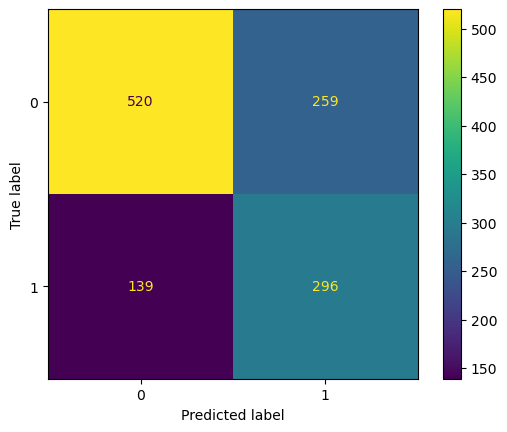

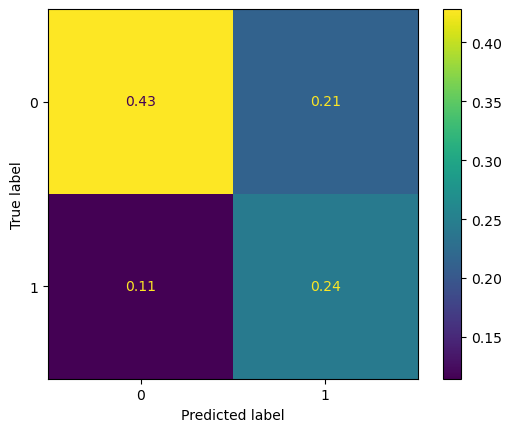

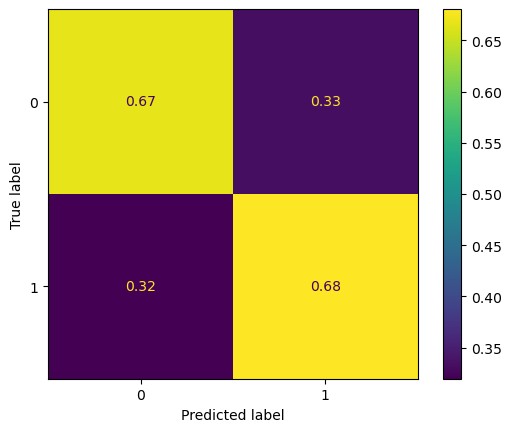


=== Raza: other ===


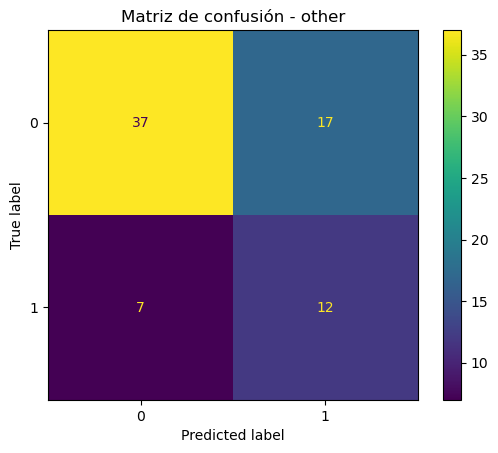

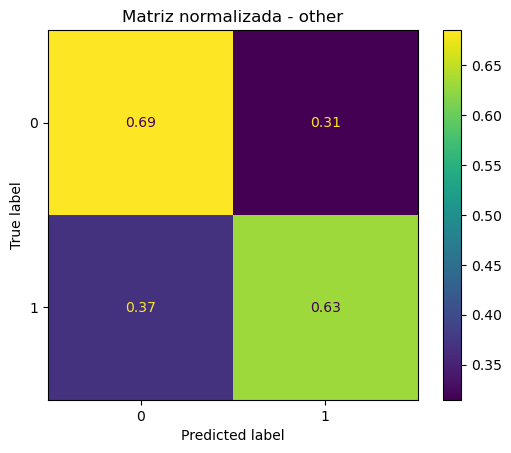

FPR: 0.315 | TPR: 0.632

=== Raza: african-american ===


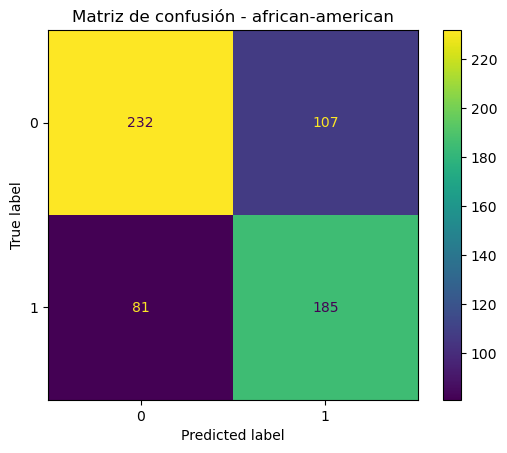

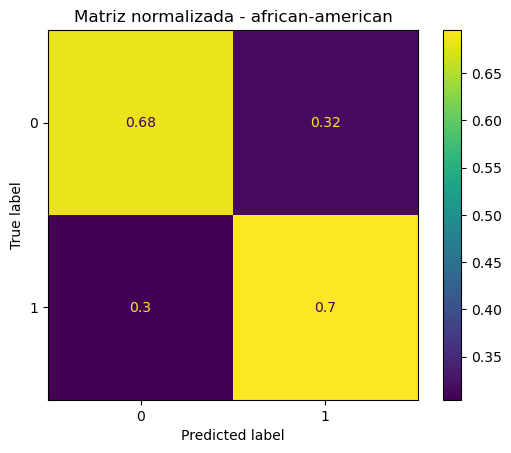

FPR: 0.316 | TPR: 0.695

=== Raza: hispanic ===


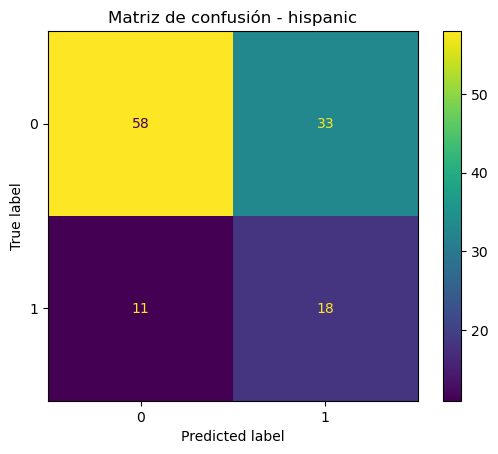

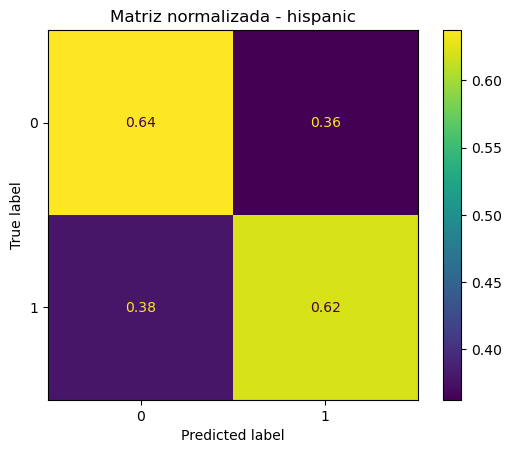

FPR: 0.363 | TPR: 0.621

=== Raza: caucasian ===


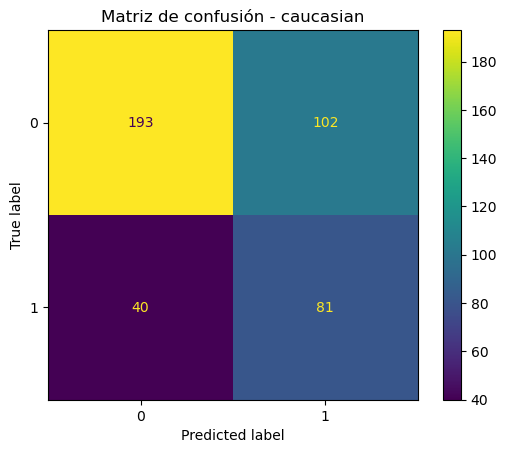

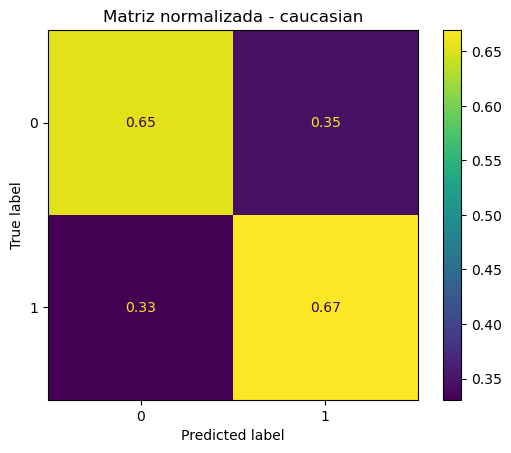

FPR: 0.346 | TPR: 0.669


In [37]:
X = df_model_scaled.drop(columns=lista_columnas_dropear)
y = df_model_scaled['two_year_recid']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=69, stratify=y
)

# -------------------------
# 2. MODELO
# -------------------------
model = LogisticRegression(
    max_iter=1000,
    penalty='l1',
    solver='liblinear',
    class_weight='balanced'
)

model.fit(X_train, y_train)

# -------------------------
# 3. PROBABILIDADES
# -------------------------
y_proba = model.predict_proba(X_test)[:, 1]

# -------------------------
# 4. RAZA (para fairness)
# -------------------------
race_test = df_sin_outliers.loc[X_test.index, 'race']

# -------------------------
# 5. DATAFRAME EVALUACIÓN
# -------------------------
df_eval = pd.DataFrame({
    'y_true': y_test,
    'y_score': y_proba,
    'race': race_test
})

# -------------------------
# 6. THRESHOLD POR RAZA
# -------------------------
thresholds = {
    'african-american': 0.53,
    'caucasian': 0.44,
    'hispanic': 0.46,
    'other': 0.47,
}

def aplicar_threshold(row):
    return int(row['y_score'] >= thresholds[row['race']])

df_eval['y_pred'] = df_eval.apply(aplicar_threshold, axis=1)

y_pred = df_eval['y_pred'].values

# -------------------------
# 7. COEFICIENTES
# -------------------------
coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': model.coef_[0]
})

print("\nCoeficientes:")
print(coeficientes.sort_values(by='Coeficiente', ascending=False))

# -------------------------
# 8. EVALUACIÓN GLOBAL
# -------------------------

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

print("ROC AUC:", roc_auc_score(y_test, y_proba))

# -------------------------
# 9. VISUALIZACIÓN GLOBAL
# -------------------------
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred))
disp.plot()

disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize="all"))
disp.plot()

disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize="true"))
disp.plot()

plt.show()

# -------------------------
# 10. FAIRNESS POR RAZA
# -------------------------
razas = df_eval['race'].unique()

for raza in razas:
    grupo = df_eval[df_eval['race'] == raza]
    
    y_true_r = grupo['y_true']
    y_pred_r = grupo['y_pred']
    
    print(f"\n=== Raza: {raza} ===")
    
    # Matriz normal
    cm = confusion_matrix(y_true_r, y_pred_r)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"Matriz de confusión - {raza}")
    plt.show()
    
    # Matriz normalizada
    cm_norm = confusion_matrix(y_true_r, y_pred_r, normalize='true')
    disp = ConfusionMatrixDisplay(cm_norm)
    disp.plot()
    plt.title(f"Matriz normalizada - {raza}")
    plt.show()
    
    # 🔥 FPR
    fp = ((y_pred_r == 1) & (y_true_r == 0)).sum()
    tn = ((y_pred_r == 0) & (y_true_r == 0)).sum()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    # 🔥 TPR
    tp = ((y_pred_r == 1) & (y_true_r == 1)).sum()
    fn = ((y_pred_r == 0) & (y_true_r == 1)).sum()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    print(f"FPR: {fpr:.3f} | TPR: {tpr:.3f}")

### Threshold por raza - sin rw sin cb


Coeficientes:
               Variable  Coeficiente
14  adult_priors_freq_2     9.319345
2      juv_priors_count     0.360392
12   is_justice_related     0.036576
11   is_public_disorder     0.024674
10            is_sexual     0.000000
0             person_id    -0.000004
5               is_drug    -0.018164
1                   age    -0.026542
6           is_property    -0.070068
8             is_weapon    -0.081883
7              is_fraud    -0.152505
13            no_charge    -0.165424
3       c_charge_degree    -0.167383
4            is_violent    -0.244483
9            is_traffic    -0.279153

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.79      0.67      0.72       779
           1       0.53      0.68      0.60       435

    accuracy                           0.67      1214
   macro avg       0.66      0.67      0.66      1214
weighted avg       0.70      0.67      0.68      1214

ROC AUC: 0.730417717970283


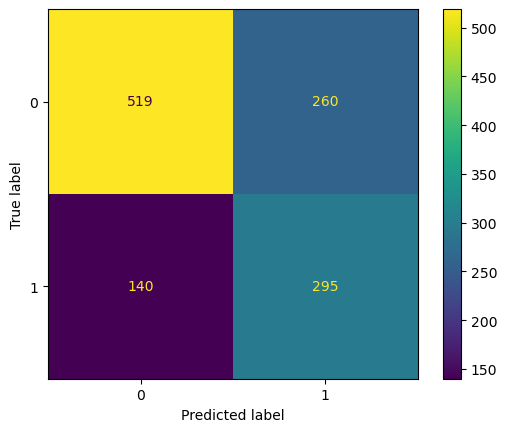

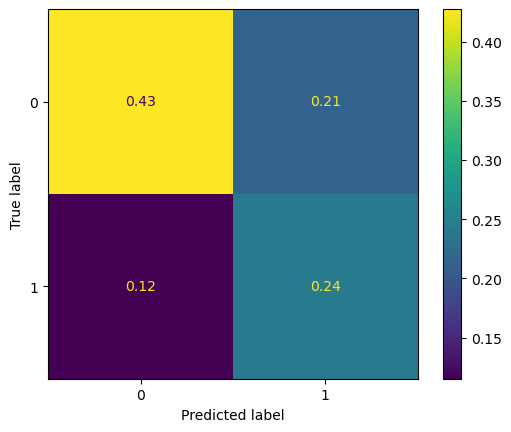

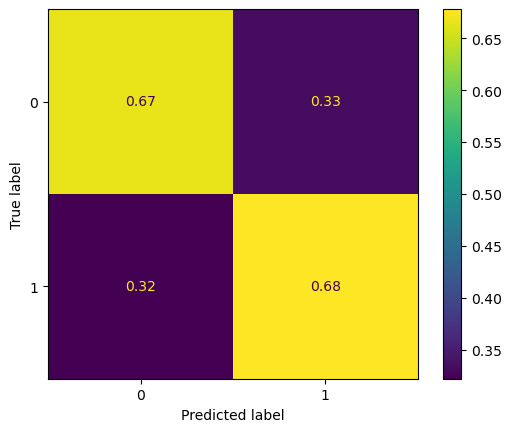


=== Raza: other ===


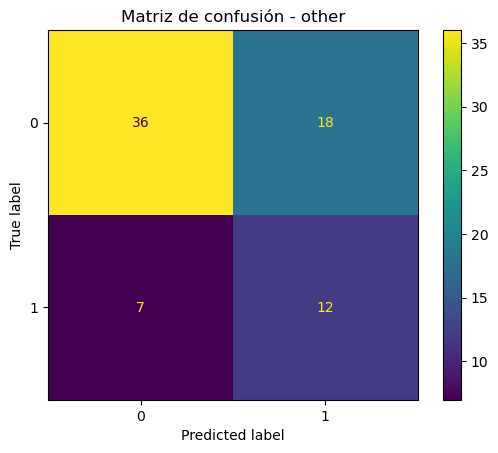

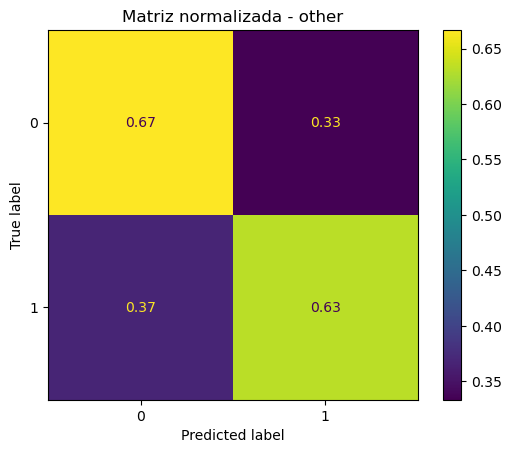

FPR: 0.333 | TPR: 0.632

=== Raza: african-american ===


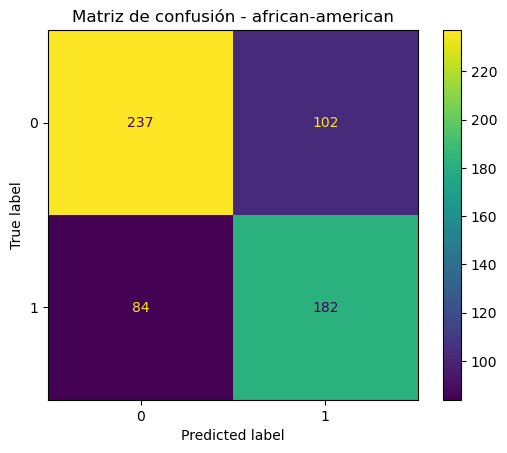

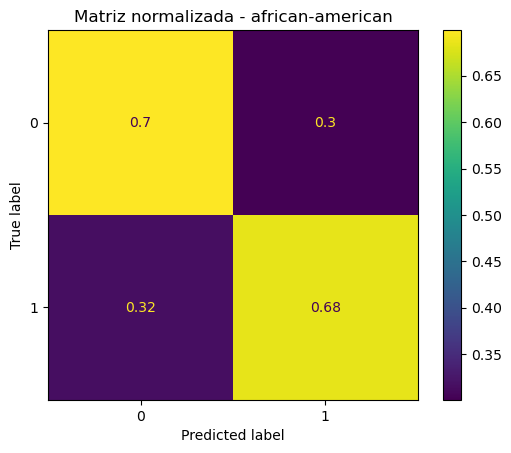

FPR: 0.301 | TPR: 0.684

=== Raza: hispanic ===


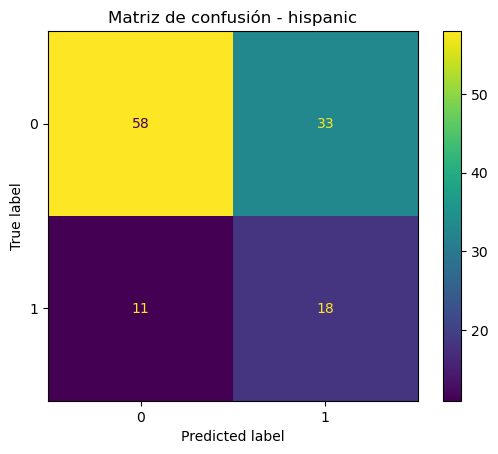

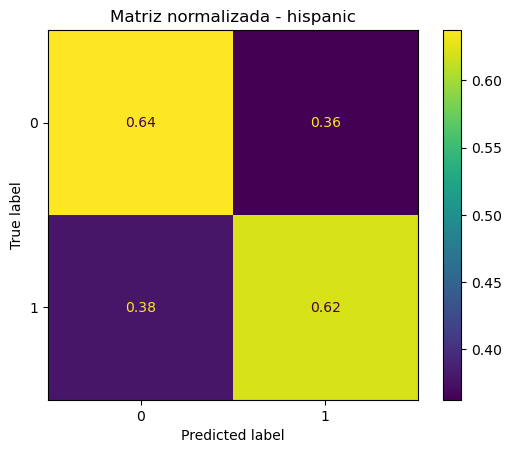

FPR: 0.363 | TPR: 0.621

=== Raza: caucasian ===


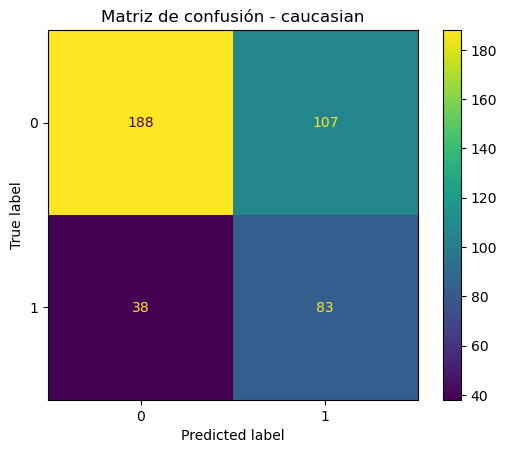

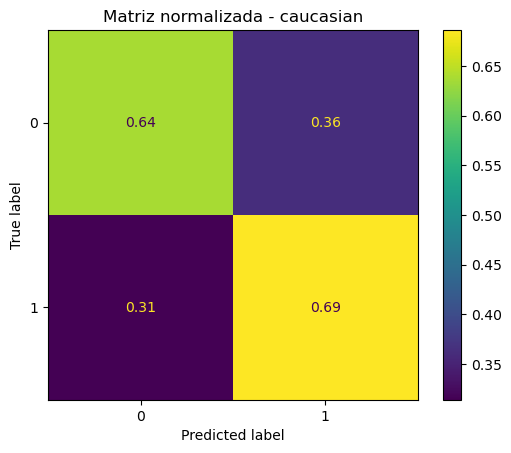

FPR: 0.363 | TPR: 0.686


In [38]:
X = df_sin_outliers.drop(columns=lista_columnas_dropear)
y = df_sin_outliers['two_year_recid']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=69, stratify=y
)

# -------------------------
# 2. MODELO
# -------------------------
model = LogisticRegression(
    max_iter=1000,
    penalty='l1',
    solver='liblinear'
)

model.fit(X_train, y_train)

# -------------------------
# 3. PROBABILIDADES
# -------------------------
y_proba = model.predict_proba(X_test)[:, 1]

# -------------------------
# 4. RAZA (para fairness)
# -------------------------
race_test = df_sin_outliers.loc[X_test.index, 'race']

# -------------------------
# 5. DATAFRAME EVALUACIÓN
# -------------------------
df_eval = pd.DataFrame({
    'y_true': y_test,
    'y_score': y_proba,
    'race': race_test
})

# -------------------------
# 6. THRESHOLD POR RAZA
# -------------------------
thresholds = {
    'african-american': 0.39,
    'caucasian': 0.3,
    'hispanic': 0.323,
    'other': 0.325
}

def aplicar_threshold(row):
    return int(row['y_score'] >= thresholds[row['race']])

df_eval['y_pred'] = df_eval.apply(aplicar_threshold, axis=1)

y_pred = df_eval['y_pred'].values

# -------------------------
# 7. COEFICIENTES
# -------------------------
coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': model.coef_[0]
})

print("\nCoeficientes:")
print(coeficientes.sort_values(by='Coeficiente', ascending=False))

# -------------------------
# 8. EVALUACIÓN GLOBAL
# -------------------------

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

print("ROC AUC:", roc_auc_score(y_test, y_proba))

# -------------------------
# 9. VISUALIZACIÓN GLOBAL
# -------------------------
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred))
disp.plot()

disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize="all"))
disp.plot()

disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize="true"))
disp.plot()

plt.show()

# -------------------------
# 10. FAIRNESS POR RAZA
# -------------------------
razas = df_eval['race'].unique()

for raza in razas:
    grupo = df_eval[df_eval['race'] == raza]
    
    y_true_r = grupo['y_true']
    y_pred_r = grupo['y_pred']
    
    print(f"\n=== Raza: {raza} ===")
    
    # Matriz normal
    cm = confusion_matrix(y_true_r, y_pred_r)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"Matriz de confusión - {raza}")
    plt.show()
    
    # Matriz normalizada
    cm_norm = confusion_matrix(y_true_r, y_pred_r, normalize='true')
    disp = ConfusionMatrixDisplay(cm_norm)
    disp.plot()
    plt.title(f"Matriz normalizada - {raza}")
    plt.show()
    
    # 🔥 FPR
    fp = ((y_pred_r == 1) & (y_true_r == 0)).sum()
    tn = ((y_pred_r == 0) & (y_true_r == 0)).sum()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    # 🔥 TPR
    tp = ((y_pred_r == 1) & (y_true_r == 1)).sum()
    fn = ((y_pred_r == 0) & (y_true_r == 1)).sum()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    print(f"FPR: {fpr:.3f} | TPR: {tpr:.3f}")

### Modelo v.2.0 - Arbol de decisión

controlando por raza


Importancia de variables:
               Variable  Importancia
14  adult_priors_freq_2     0.642893
1                   age     0.233615
2      juv_priors_count     0.058737
9            is_traffic     0.021796
0             person_id     0.018500
13            no_charge     0.012735
5               is_drug     0.008701
4            is_violent     0.003023
3       c_charge_degree     0.000000
6           is_property     0.000000
7              is_fraud     0.000000
10            is_sexual     0.000000
8             is_weapon     0.000000
12   is_justice_related     0.000000
11   is_public_disorder     0.000000

Matriz de confusión:
[[487 292]
 [127 308]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.79      0.63      0.70       779
           1       0.51      0.71      0.60       435

    accuracy                           0.65      1214
   macro avg       0.65      0.67      0.65      1214
weighted avg       0.69      0.65    

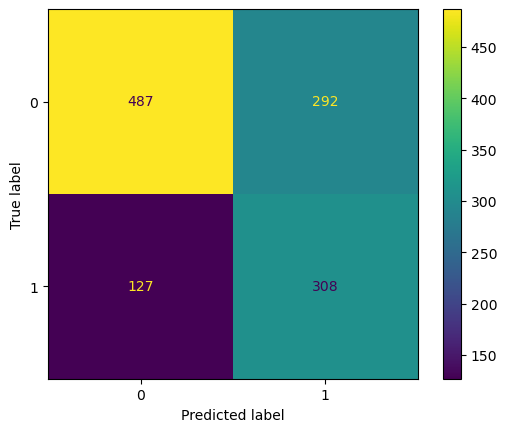

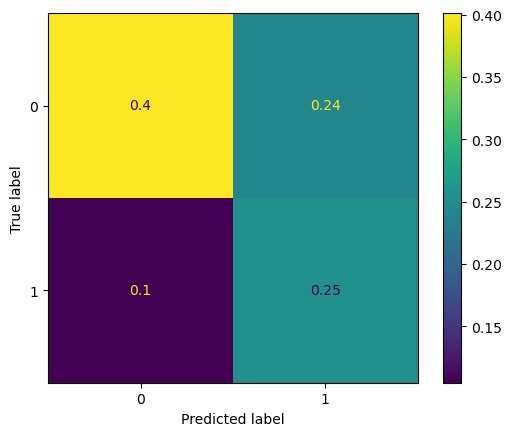

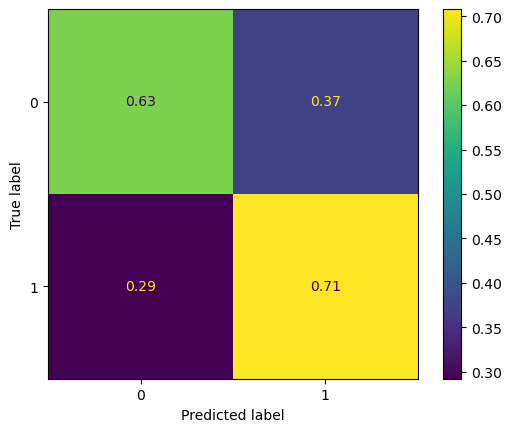


=== Raza: other ===


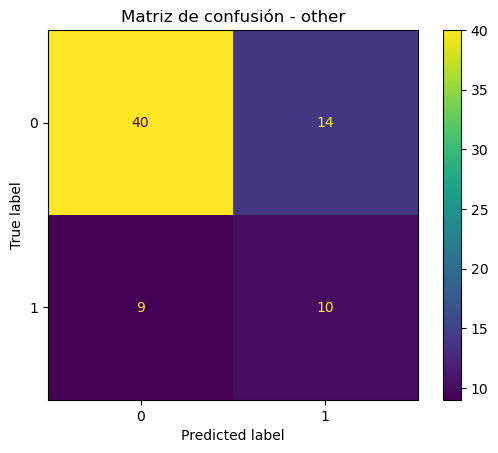

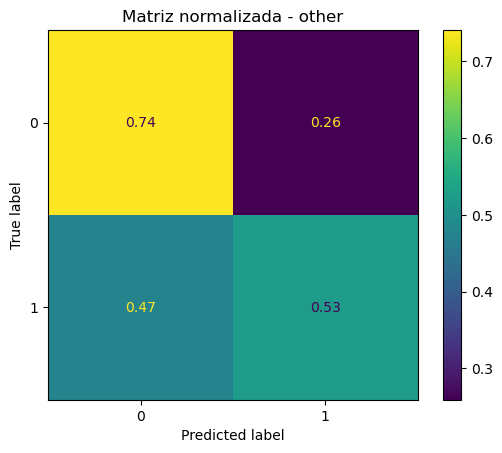

FPR: 0.259 | TPR: 0.526

=== Raza: african-american ===


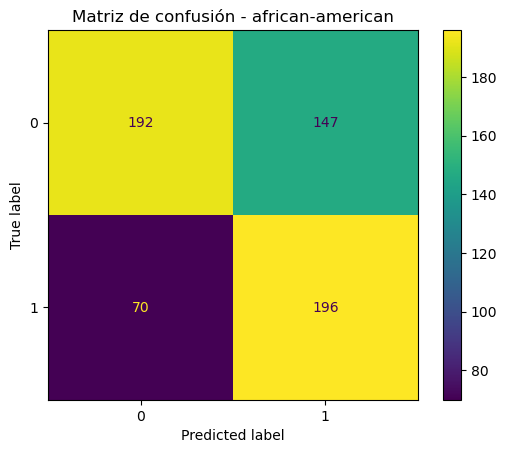

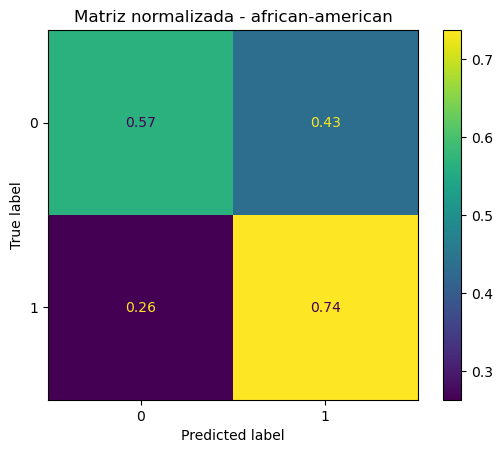

FPR: 0.434 | TPR: 0.737

=== Raza: hispanic ===


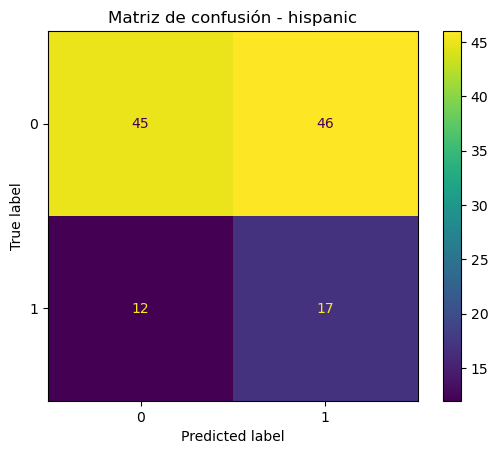

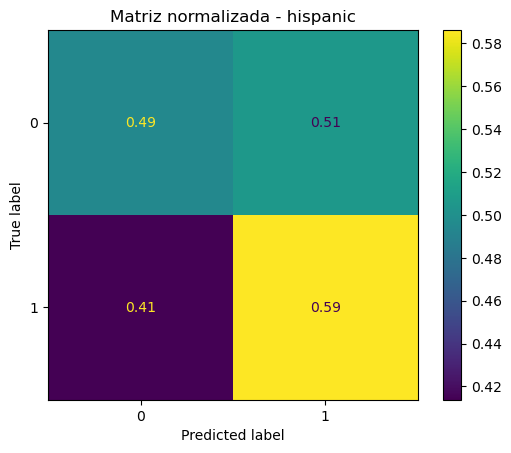

FPR: 0.505 | TPR: 0.586

=== Raza: caucasian ===


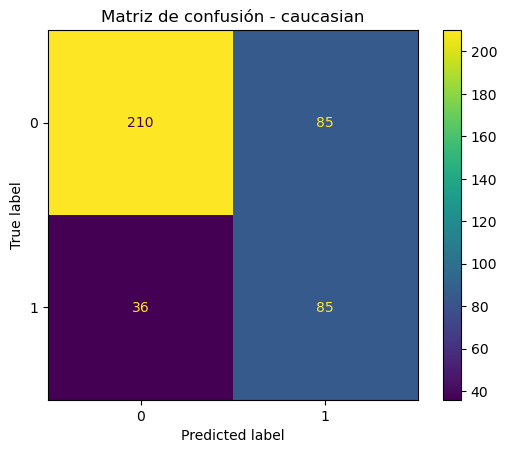

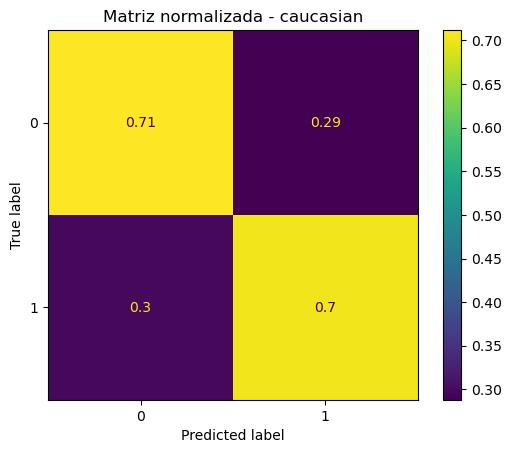

FPR: 0.288 | TPR: 0.702


In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    ConfusionMatrixDisplay
)

# -------------------------
# 1. DATOS
# -------------------------
X = df_sin_outliers.drop(columns=lista_columnas_dropear)
y = df_sin_outliers['two_year_recid']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=69, stratify=y
)

# -------------------------
# 2. MODELO (ÁRBOL)
# -------------------------
model = DecisionTreeClassifier(
    max_depth=5,              # 👈 importante para evitar overfitting
    min_samples_leaf=20,      # 👈 estabiliza el modelo
    class_weight='balanced',  # 👈 equivalente a lo que hacías antes
    random_state=69
)

model.fit(X_train, y_train)

# -------------------------
# 3. PROBABILIDADES
# -------------------------
y_proba = model.predict_proba(X_test)[:, 1]

# -------------------------
# 4. RAZA
# -------------------------
race_test = df_sin_outliers.loc[X_test.index, 'race']

# -------------------------
# 5. DATAFRAME EVALUACIÓN
# -------------------------
df_eval = pd.DataFrame({
    'y_true': y_test,
    'y_score': y_proba,
    'race': race_test
})

# -------------------------
# 6. THRESHOLD POR RAZA
# -------------------------
thresholds = {
    'african-american': 0.5,
    'caucasian': 0.45,
    'hispanic': 0.3625,
    'other': 0.47
}

def aplicar_threshold(row):
    return int(row['y_score'] >= thresholds[row['race']])

df_eval['y_pred'] = df_eval.apply(aplicar_threshold, axis=1)
y_pred = df_eval['y_pred'].values

# -------------------------
# 7. IMPORTANCIA VARIABLES
# -------------------------
importancias = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': model.feature_importances_
})

print("\nImportancia de variables:")
print(importancias.sort_values(by='Importancia', ascending=False))

# -------------------------
# 8. EVALUACIÓN GLOBAL
# -------------------------
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

print("ROC AUC:", roc_auc_score(y_test, y_proba))

# -------------------------
# 9. VISUALIZACIÓN GLOBAL
# -------------------------
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred))
disp.plot()

disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize="all"))
disp.plot()

disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize="true"))
disp.plot()

plt.show()

# -------------------------
# 10. FAIRNESS POR RAZA
# -------------------------
razas = df_eval['race'].unique()

for raza in razas:
    grupo = df_eval[df_eval['race'] == raza]
    
    y_true_r = grupo['y_true']
    y_pred_r = grupo['y_pred']
    
    print(f"\n=== Raza: {raza} ===")
    
    # Matriz normal
    cm = confusion_matrix(y_true_r, y_pred_r)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"Matriz de confusión - {raza}")
    plt.show()
    
    # Matriz normalizada
    cm_norm = confusion_matrix(y_true_r, y_pred_r, normalize='true')
    disp = ConfusionMatrixDisplay(cm_norm)
    disp.plot()
    plt.title(f"Matriz normalizada - {raza}")
    plt.show()
    
    # FPR
    fp = ((y_pred_r == 1) & (y_true_r == 0)).sum()
    tn = ((y_pred_r == 0) & (y_true_r == 0)).sum()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    # TPR
    tp = ((y_pred_r == 1) & (y_true_r == 1)).sum()
    fn = ((y_pred_r == 0) & (y_true_r == 1)).sum()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    print(f"FPR: {fpr:.3f} | TPR: {tpr:.3f}")

Matriz de confusión:
[[533 246]
 [153 282]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.78      0.68      0.73       779
           1       0.53      0.65      0.59       435

    accuracy                           0.67      1214
   macro avg       0.66      0.67      0.66      1214
weighted avg       0.69      0.67      0.68      1214

ROC AUC: 0.7262493913505377

Importancia de variables:
               Variable  Importancia
14  adult_priors_freq_2     0.749127
1                   age     0.125828
2      juv_priors_count     0.033659
0             person_id     0.031986
13            no_charge     0.031540
3       c_charge_degree     0.014451
9            is_traffic     0.013409
6           is_property     0.000000
5               is_drug     0.000000
4            is_violent     0.000000
7              is_fraud     0.000000
10            is_sexual     0.000000
8             is_weapon     0.000000
12   is_justice_related     0

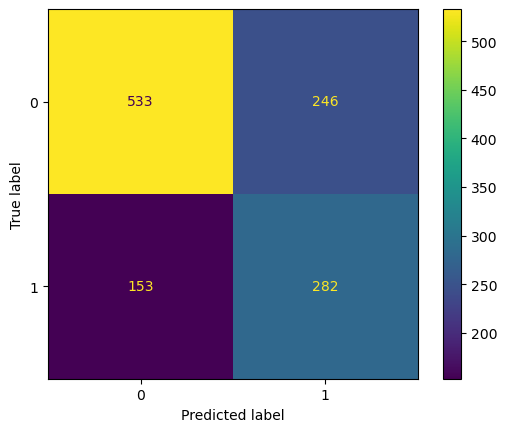

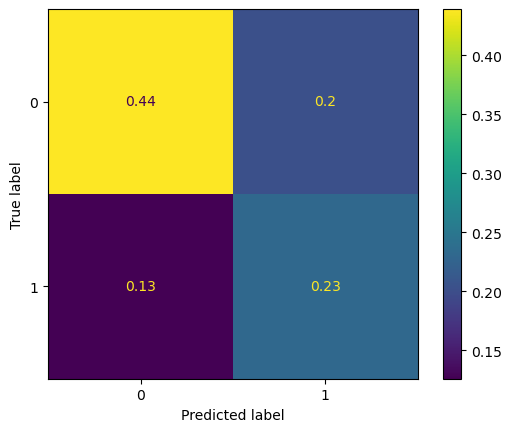

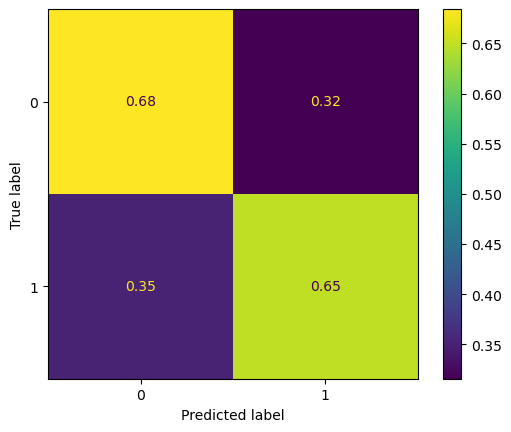


=== Raza: other ===


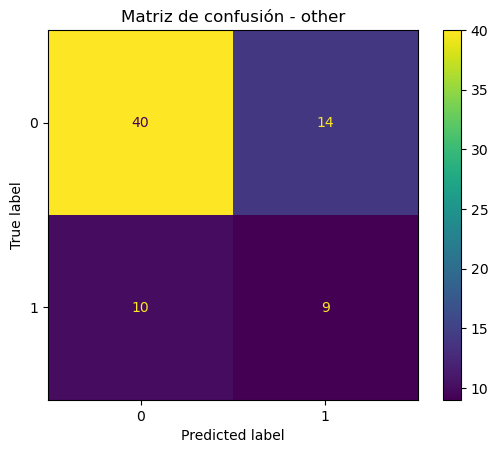

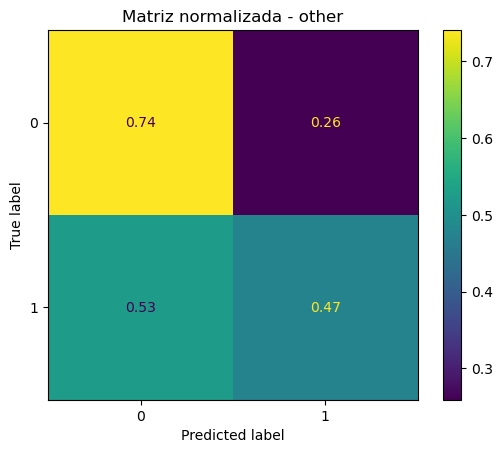

FPR: 0.259 | TPR: 0.474

=== Raza: african-american ===


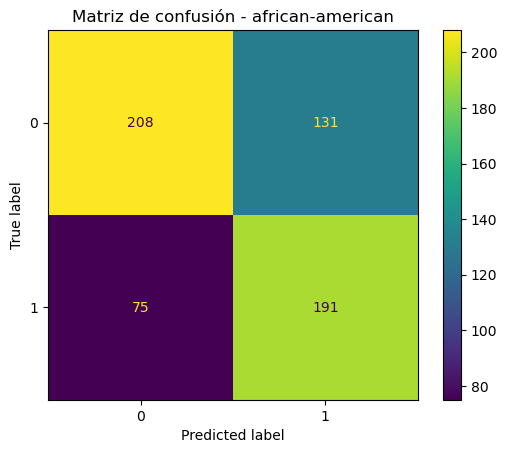

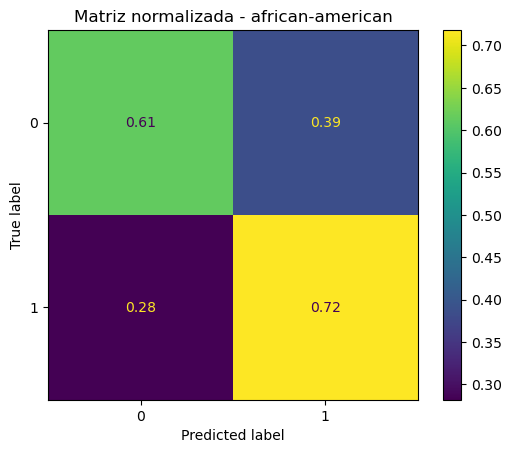

FPR: 0.386 | TPR: 0.718

=== Raza: hispanic ===


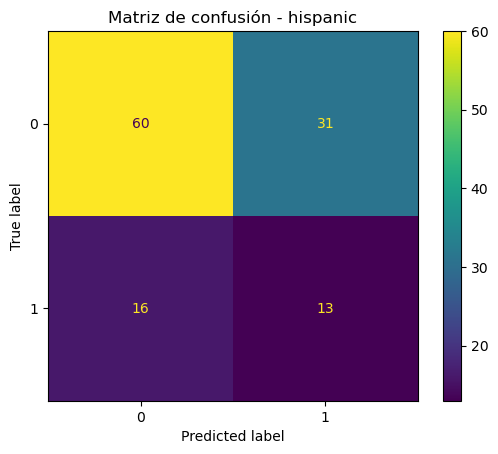

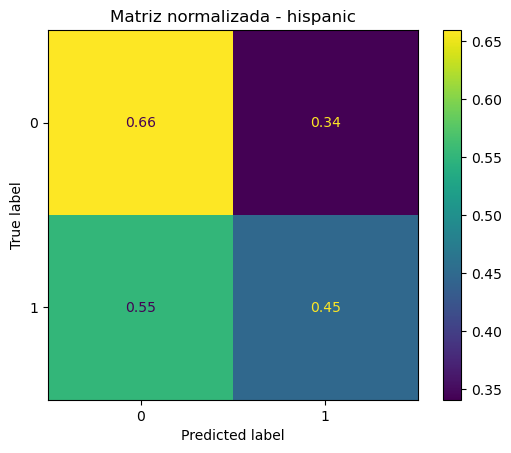

FPR: 0.341 | TPR: 0.448

=== Raza: caucasian ===


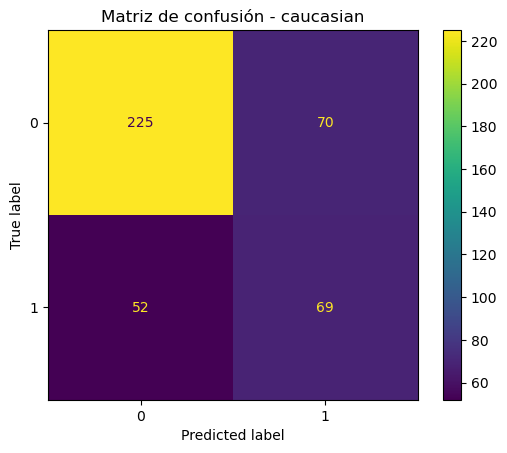

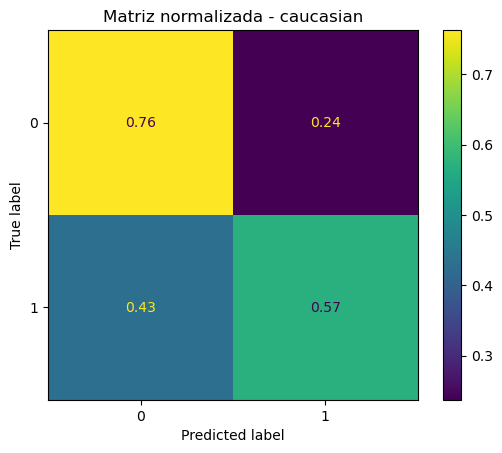

FPR: 0.237 | TPR: 0.570


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    ConfusionMatrixDisplay
)

# -------------------------
# 1. DATOS
# -------------------------
X = df_sin_outliers.drop(columns=lista_columnas_dropear)
y = df_sin_outliers['two_year_recid']
race = df_sin_outliers['race']

X_train, X_test, y_train, y_test, race_train, race_test = train_test_split(
    X, y, race,
    test_size=0.2,
    random_state=69,
    stratify=y
)

# -------------------------
# 2. PESOS POR CLASE
# -------------------------
conteo = y_train.value_counts()
total = len(y_train)

peso_0 = total / (2 * conteo[0])
peso_1 = total / (2 * conteo[1])

w_class = y_train.map({
    0: peso_0,
    1: peso_1
})

# -------------------------
# 3. PESOS POR RAZA
# -------------------------
dist_raza = race_train.value_counts(normalize=True)

peso_raza = {r: 1 / np.sqrt(dist_raza[r]) for r in dist_raza.index}

w_race = race_train.map(peso_raza)

# -------------------------
# 4. PESO FINAL
# -------------------------
w_train = w_class * w_race

# -------------------------
# 5. MODELO (ÁRBOL)
# -------------------------
model = DecisionTreeClassifier(
    max_depth=5,           # 👈 importante para estabilidad
    min_samples_leaf=20,   # 👈 evita overfitting
    random_state=69
)

model.fit(X_train, y_train, sample_weight=w_train)

# -------------------------
# 6. PREDICCIONES
# -------------------------
y_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

# -------------------------
# 7. RESULTADOS GLOBALES
# -------------------------

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

print("ROC AUC:", roc_auc_score(y_test, y_proba))

# -------------------------
# 8. IMPORTANCIA VARIABLES
# -------------------------
importancias = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': model.feature_importances_
})

print("\nImportancia de variables:")
print(importancias.sort_values(by='Importancia', ascending=False))

# -------------------------
# 9. VISUALIZACIÓN GLOBAL
# -------------------------
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred))
disp.plot()

disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize="all"))
disp.plot()

disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, normalize="true"))
disp.plot()

plt.show()

# -------------------------
# 10. FAIRNESS POR RAZA
# -------------------------
race_test = df_sin_outliers.loc[X_test.index, 'race']

for raza in race_test.unique():
    idx = race_test == raza
    
    y_true_r = y_test[idx]
    y_pred_r = y_pred[idx]
    
    print(f"\n=== Raza: {raza} ===")
    
    # Matriz normal
    cm = confusion_matrix(y_true_r, y_pred_r)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"Matriz de confusión - {raza}")
    plt.show()
    
    # Matriz normalizada
    cm_norm = confusion_matrix(y_true_r, y_pred_r, normalize='true')
    disp = ConfusionMatrixDisplay(cm_norm)
    disp.plot()
    plt.title(f"Matriz normalizada - {raza}")
    plt.show()
    
    # 🔥 FPR
    fp = ((y_pred_r == 1) & (y_true_r == 0)).sum()
    tn = ((y_pred_r == 0) & (y_true_r == 0)).sum()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    # 🔥 TPR
    tp = ((y_pred_r == 1) & (y_true_r == 1)).sum()
    fn = ((y_pred_r == 0) & (y_true_r == 1)).sum()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    print(f"FPR: {fpr:.3f} | TPR: {tpr:.3f}")

Matriz de confusión:
[[516 263]
 [139 296]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.79      0.66      0.72       779
           1       0.53      0.68      0.60       435

    accuracy                           0.67      1214
   macro avg       0.66      0.67      0.66      1214
weighted avg       0.70      0.67      0.68      1214

ROC AUC: 0.722858660528529

Importancia de variables:
               Variable  Importancia
14  adult_priors_freq_2     0.642893
1                   age     0.233615
2      juv_priors_count     0.058737
9            is_traffic     0.021796
0             person_id     0.018500
13            no_charge     0.012735
5               is_drug     0.008701
4            is_violent     0.003023
3       c_charge_degree     0.000000
6           is_property     0.000000
7              is_fraud     0.000000
10            is_sexual     0.000000
8             is_weapon     0.000000
12   is_justice_related     0.

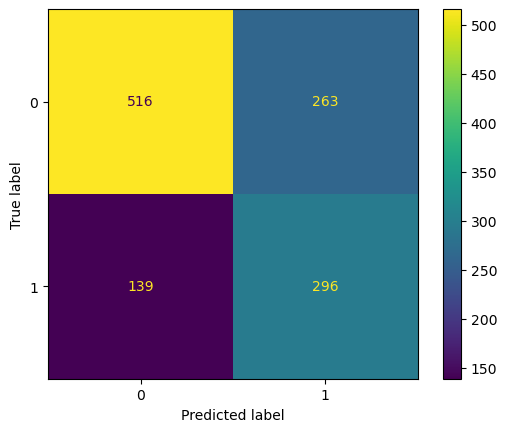

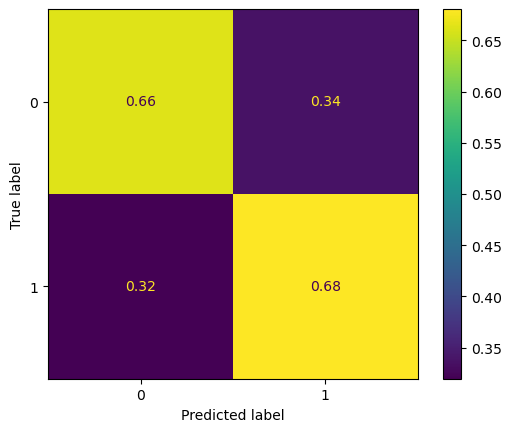


=== Raza: african-american ===


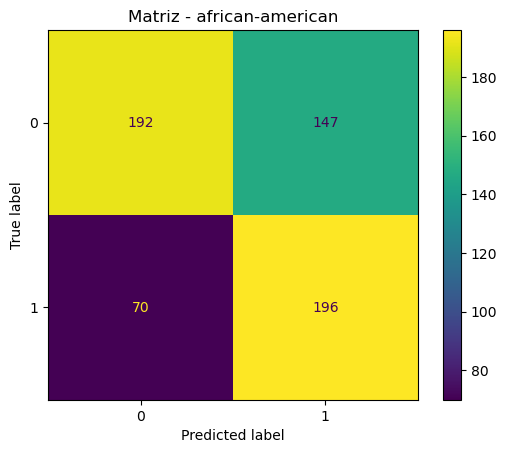

FPR: 0.434 | TPR: 0.737

=== Raza: caucasian ===


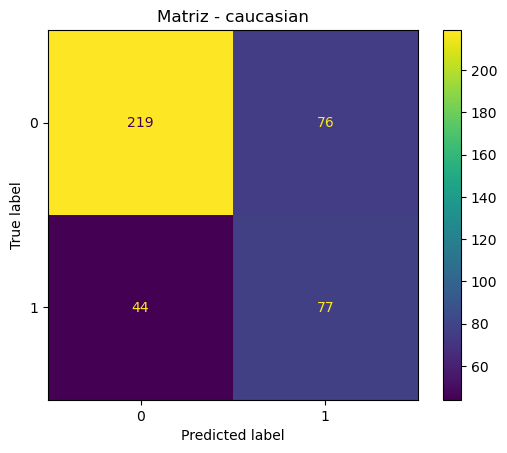

FPR: 0.258 | TPR: 0.636

=== Raza: hispanic ===


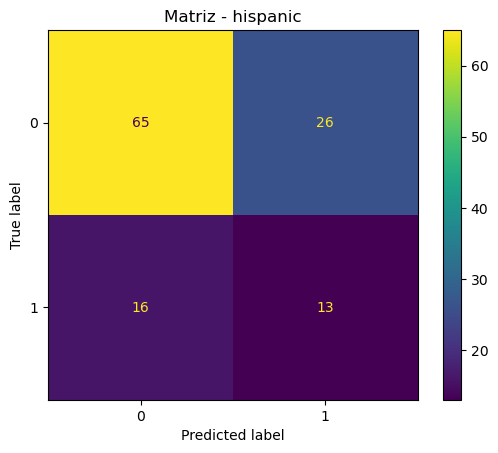

FPR: 0.286 | TPR: 0.448

=== Raza: other ===


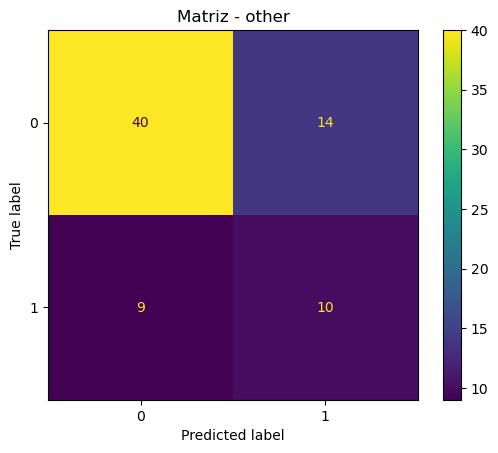

FPR: 0.259 | TPR: 0.526


In [41]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    ConfusionMatrixDisplay
)

# -------------------------
# 1. DATOS
# -------------------------
X = df_sin_outliers.drop(columns=lista_columnas_dropear)
y = df_sin_outliers['two_year_recid']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=69, stratify=y
)

# -------------------------
# 2. MODELO (ÁRBOL)
# -------------------------
model = DecisionTreeClassifier(
    max_depth=5,              # 👈 controla complejidad
    min_samples_leaf=20,      # 👈 evita ruido
    class_weight='balanced',  # 👈 balanceo de clases
    random_state=69
)

model.fit(X_train, y_train)

# -------------------------
# 3. PREDICCIONES
# -------------------------
y_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

# -------------------------
# 4. RESULTADOS GLOBALES
# -------------------------
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

print("ROC AUC:", roc_auc_score(y_test, y_proba))

# -------------------------
# 5. IMPORTANCIA VARIABLES
# -------------------------
importancias = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': model.feature_importances_
})

print("\nImportancia de variables:")
print(importancias.sort_values(by='Importancia', ascending=False))

# -------------------------
# 6. VISUALIZACIÓN GLOBAL
# -------------------------
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, normalize="true")

plt.show()

# -------------------------
# 7. FAIRNESS POR RAZA
# -------------------------
race_test = df_sin_outliers.loc[X_test.index, 'race']

df_eval = pd.DataFrame({
    'y_true': y_test,
    'y_pred': y_pred,
    'race': race_test
})

for raza, grupo in df_eval.groupby('race'):
    print(f"\n=== Raza: {raza} ===")
    
    cm = confusion_matrix(grupo['y_true'], grupo['y_pred'])
    disp = ConfusionMatrixDisplay(cm)
    disp.plot()
    plt.title(f"Matriz - {raza}")
    plt.show()
    
    # FPR
    fp = ((grupo['y_pred'] == 1) & (grupo['y_true'] == 0)).sum()
    tn = ((grupo['y_pred'] == 0) & (grupo['y_true'] == 0)).sum()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    # TPR
    tp = ((grupo['y_pred'] == 1) & (grupo['y_true'] == 1)).sum()
    fn = ((grupo['y_pred'] == 0) & (grupo['y_true'] == 1)).sum()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    print(f"FPR: {fpr:.3f} | TPR: {tpr:.3f}")